# Membership Inference Attack (MIA) — Visualization

Publication-quality graphs for the MIA evaluation.

**Source:** `consolidated_mia_data.csv` (generated by `prepare_mia_data.py`)
**Attacks available:** `lira`, `shokri`, `yeom` — select with `ATTACK` below
**Metric:** Privacy Leakage = Advantage (TPR − FPR)
**Datasets:** Breast Cancer, Diabetes, Cancer Risk, Gallstone, Kidney Stone, Lung Cancer
**Models:** DP-RF, DP-LR, DP-GNB, DP-SVM, DP-DNN + Standard baselines

Figures are written to `figures/` prefixed with the attack name.


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Publication-quality settings (IEEE/Nature style)
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Computer Modern Roman'],
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'legend.fontsize': 7.5,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.4,
    'lines.linewidth': 1.5,
    'lines.markersize': 5,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'legend.framealpha': 0.9,
    'legend.edgecolor': '#cccccc',
    'figure.constrained_layout.use': True,
    'mathtext.fontset': 'cm',
})

# Which attack to plot: 'lira' | 'shokri' | 'yeom'
# LiRA is the strongest (likelihood-ratio, TPR at low FPR); re-run this notebook
# with a different value to regenerate the other two sets.
ATTACK = 'lira'

DATA_FILE = Path('consolidated_mia_data.csv')
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"consolidated_mia_data.csv not found. Run: python prepare_mia_data.py"
    )

GRAPH_DIR = Path('figures')
GRAPH_DIR.mkdir(exist_ok=True)

print(f"Data file: {DATA_FILE}")
print(f"Attack:    {ATTACK}")
print(f"Graphs:    {GRAPH_DIR}/{ATTACK}_*")


Data file: consolidated_mia_data.csv
Attack:    lira
Graphs:    figures/lira_*


In [2]:
# Load consolidated attack results (CSV is the canonical source)
df_raw = pd.read_csv(DATA_FILE)
df_att = df_raw[df_raw['attack'] == ATTACK].copy()
if df_att.empty:
    raise ValueError(f"No rows for attack={ATTACK!r}. Available: "
                     f"{sorted(df_raw['attack'].unique())}")

DATASET_SIZES = df_raw.groupby('dataset')['n_samples'].first().to_dict()

# The CSV names families RF/LR/GNB/SVM/DNN; the figures label them DP-* for the
# private targets and "Standard *" for the non-private ones.
df_dp = df_att[df_att['variant'] == 'dp'].copy()
df_dp['model'] = 'DP-' + df_dp['model']
df_dp['epsilon'] = pd.to_numeric(df_dp['epsilon'], errors='coerce')

df_baseline = df_att[df_att['variant'] == 'standard'].copy()
df_baseline['model'] = 'Standard ' + df_baseline['model']

MODEL_MAP = {
    'Standard RF': 'DP-RF', 'Standard LR': 'DP-LR',
    'Standard GNB': 'DP-GNB', 'Standard SVM': 'DP-SVM',
    'Standard DNN': 'DP-DNN',
}
df_baseline['dp_equivalent'] = df_baseline['model'].map(MODEL_MAP)

# LiRA and Yeom report single-run values, so their *_std columns are blank.
# Zero-fill so error bands collapse to the line instead of vanishing.
for col in ('advantage_std', 'attack_auc_std'):
    if col in df_dp:
        df_dp[col] = df_dp[col].fillna(0.0)
        df_baseline[col] = df_baseline[col].fillna(0.0)

print(f"Attack: {ATTACK}")
print(f"Datasets: {sorted(df_att['dataset'].unique())}")
print(f"DP Models: {sorted(df_dp['model'].unique())}")
print(f"Epsilon values: {sorted(df_dp['epsilon'].dropna().unique())}")
print(f"DP records: {len(df_dp)}, Baselines: {len(df_baseline)}")


Attack: lira
Datasets: ['Breast Cancer', 'Cancer Risk', 'Diabetes', 'Gallstone', 'Kidney Stone', 'Lung Cancer']
DP Models: ['DP-DNN', 'DP-GNB', 'DP-LR', 'DP-RF', 'DP-SVM']
Epsilon values: [np.float64(0.1), np.float64(0.2), np.float64(0.4), np.float64(0.8), np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(10.0)]
DP records: 270, Baselines: 30


In [3]:
# Color scheme (Tol's vibrant — colorblind-friendly, consistent with main paper graphs)
MODEL_COLORS = {
    'DP-RF': '#009E73',    # Bluish green
    'DP-LR': '#D55E00',    # Vermillion
    'DP-GNB': '#CC79A7',   # Reddish purple
    'DP-SVM': '#0072B2',   # Blue
    'DP-DNN': '#E69F00',   # Orange
}

MODEL_MARKERS = {
    'DP-RF': 'o',
    'DP-LR': 's',
    'DP-GNB': '^',
    'DP-SVM': 'D',
    'DP-DNN': 'v',
}

MODEL_LINESTYLES = {
    'DP-RF': '-',
    'DP-LR': '--',
    'DP-GNB': '-.',
    'DP-SVM': ':',
    'DP-DNN': (0, (3, 1, 1, 1)),
}

DATASET_COLORS = {
    'Breast Cancer': '#CC6677',
    'Cancer Risk': '#DDCC77',
    'Diabetes': '#117733',
    'Gallstone': '#332288',
    'Kidney Stone': '#88CCEE',
    'Lung Cancer': '#AA4499',
}

DATASET_MARKERS = {
    'Breast Cancer': 'o',
    'Cancer Risk': 's',
    'Diabetes': '^',
    'Gallstone': 'D',
    'Kidney Stone': 'v',
    'Lung Cancer': 'P',
}

DATASET_LINESTYLES = {
    'Breast Cancer': '-',
    'Cancer Risk': '--',
    'Diabetes': '-.',
    'Gallstone': ':',
    'Kidney Stone': (0, (3, 1, 1, 1)),
    'Lung Cancer': (0, (5, 1)),
}

# Ordered by sample count ascending (Gallstone smallest -> Diabetes largest),
# consistent with Results/dataset_results/graph_construction.ipynb.
DATASETS_ORDER = sorted(DATASET_SIZES, key=lambda d: DATASET_SIZES[d])
MODELS_ORDER = ['DP-RF', 'DP-LR', 'DP-GNB', 'DP-SVM', 'DP-DNN']

---
## Figures 1a–1e: Privacy Leakage vs ε (One per Dataset)

Individual clean plots for each dataset showing how privacy leakage changes with the privacy budget.

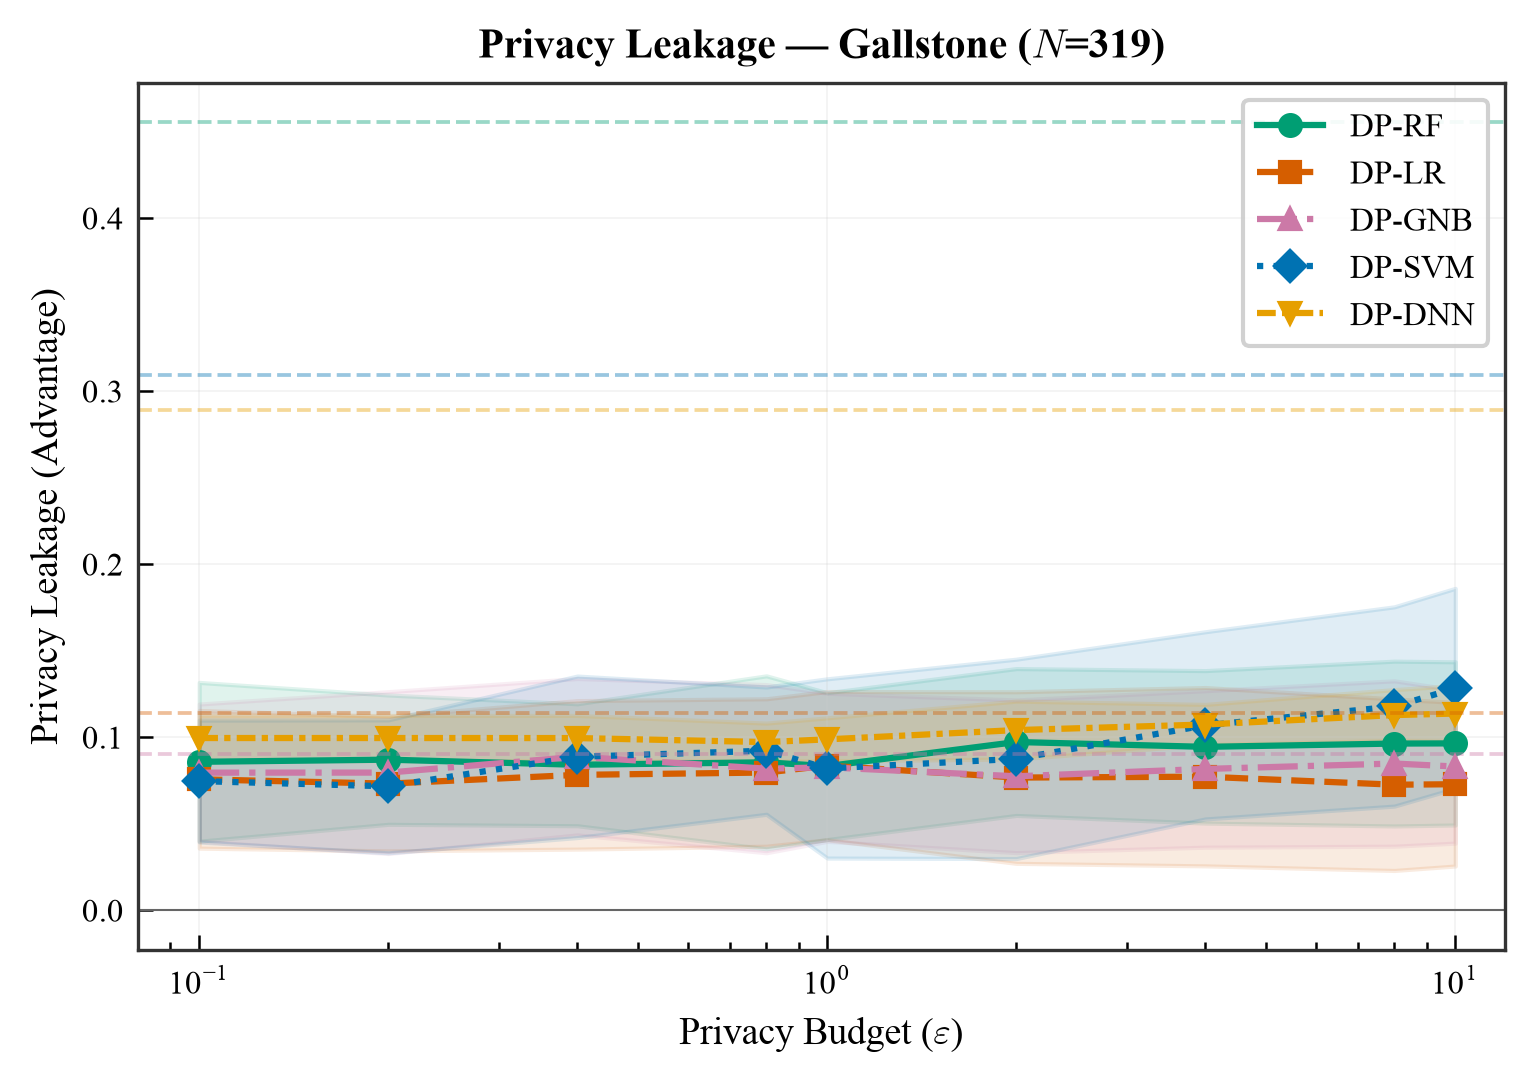

Saved: fig1_gallstone_privacy_leakage.pdf / .png


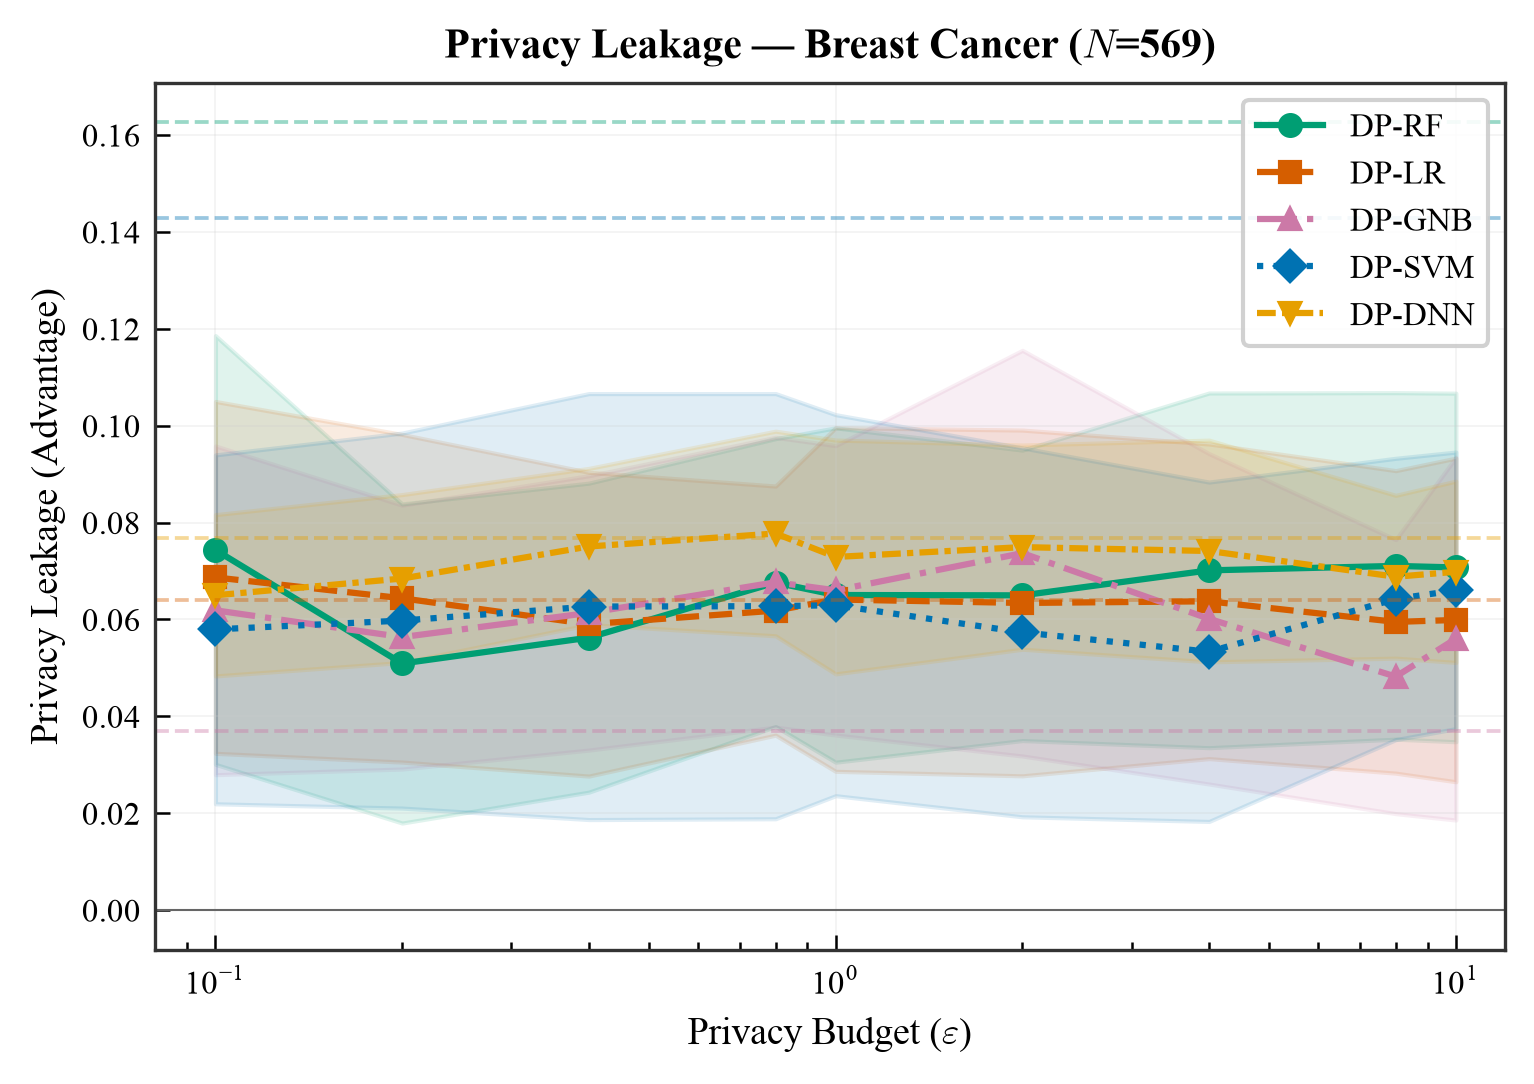

Saved: fig1_breast_cancer_privacy_leakage.pdf / .png


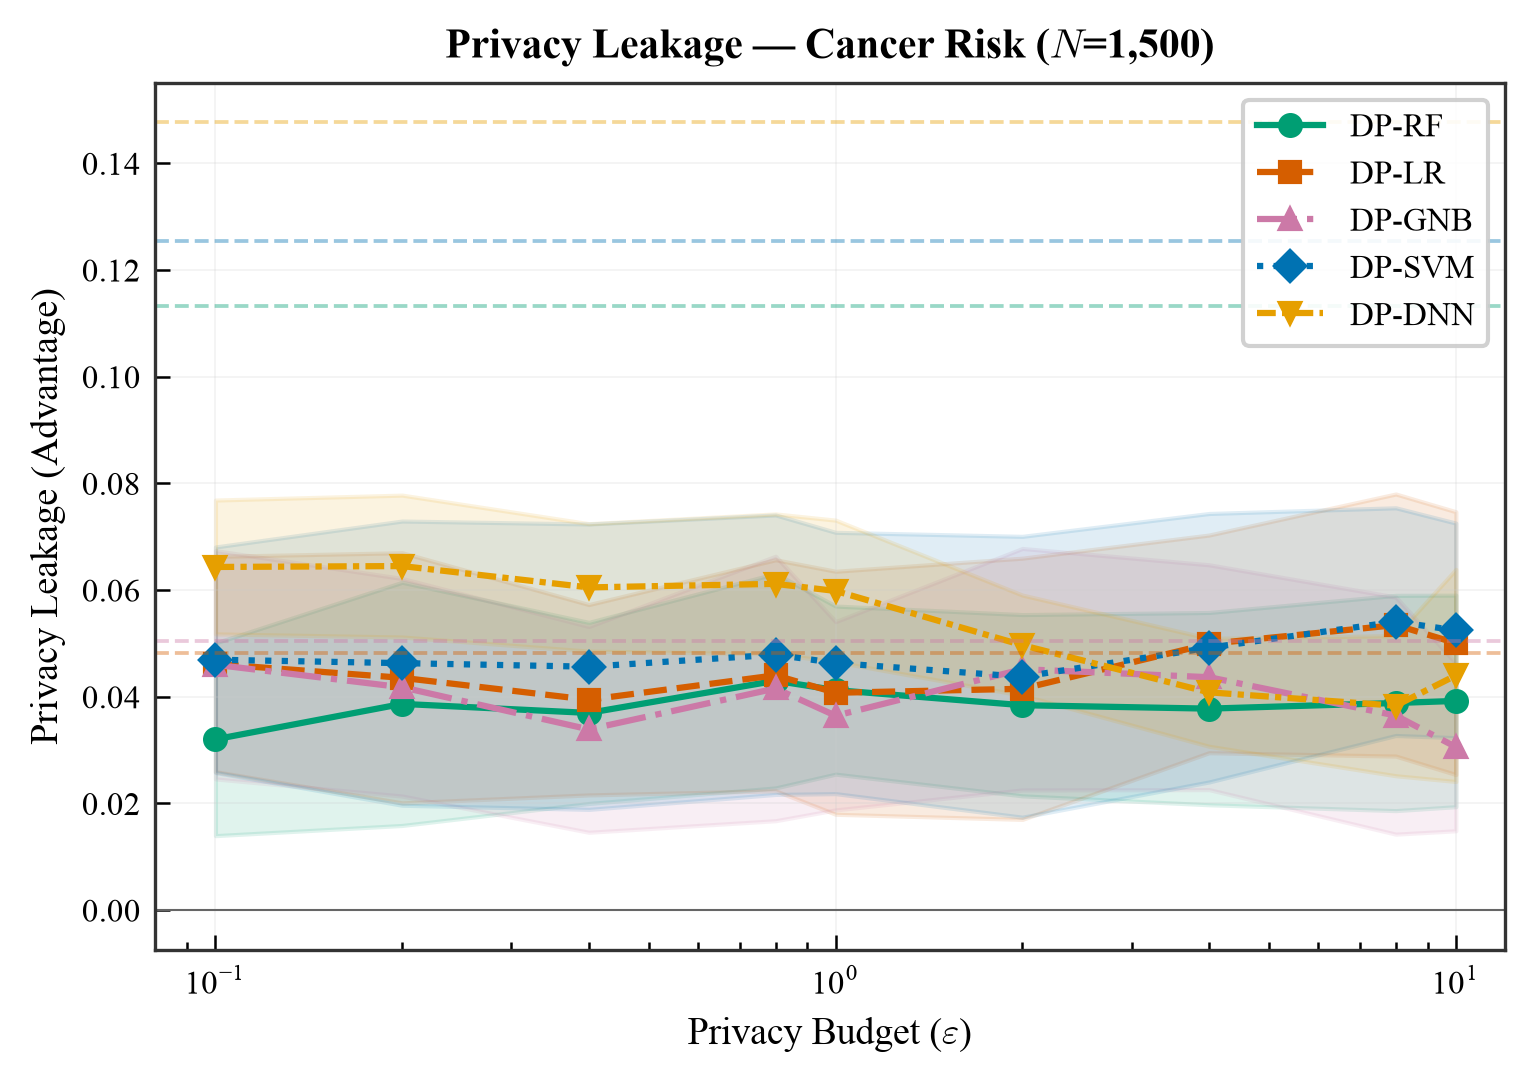

Saved: fig1_cancer_risk_privacy_leakage.pdf / .png


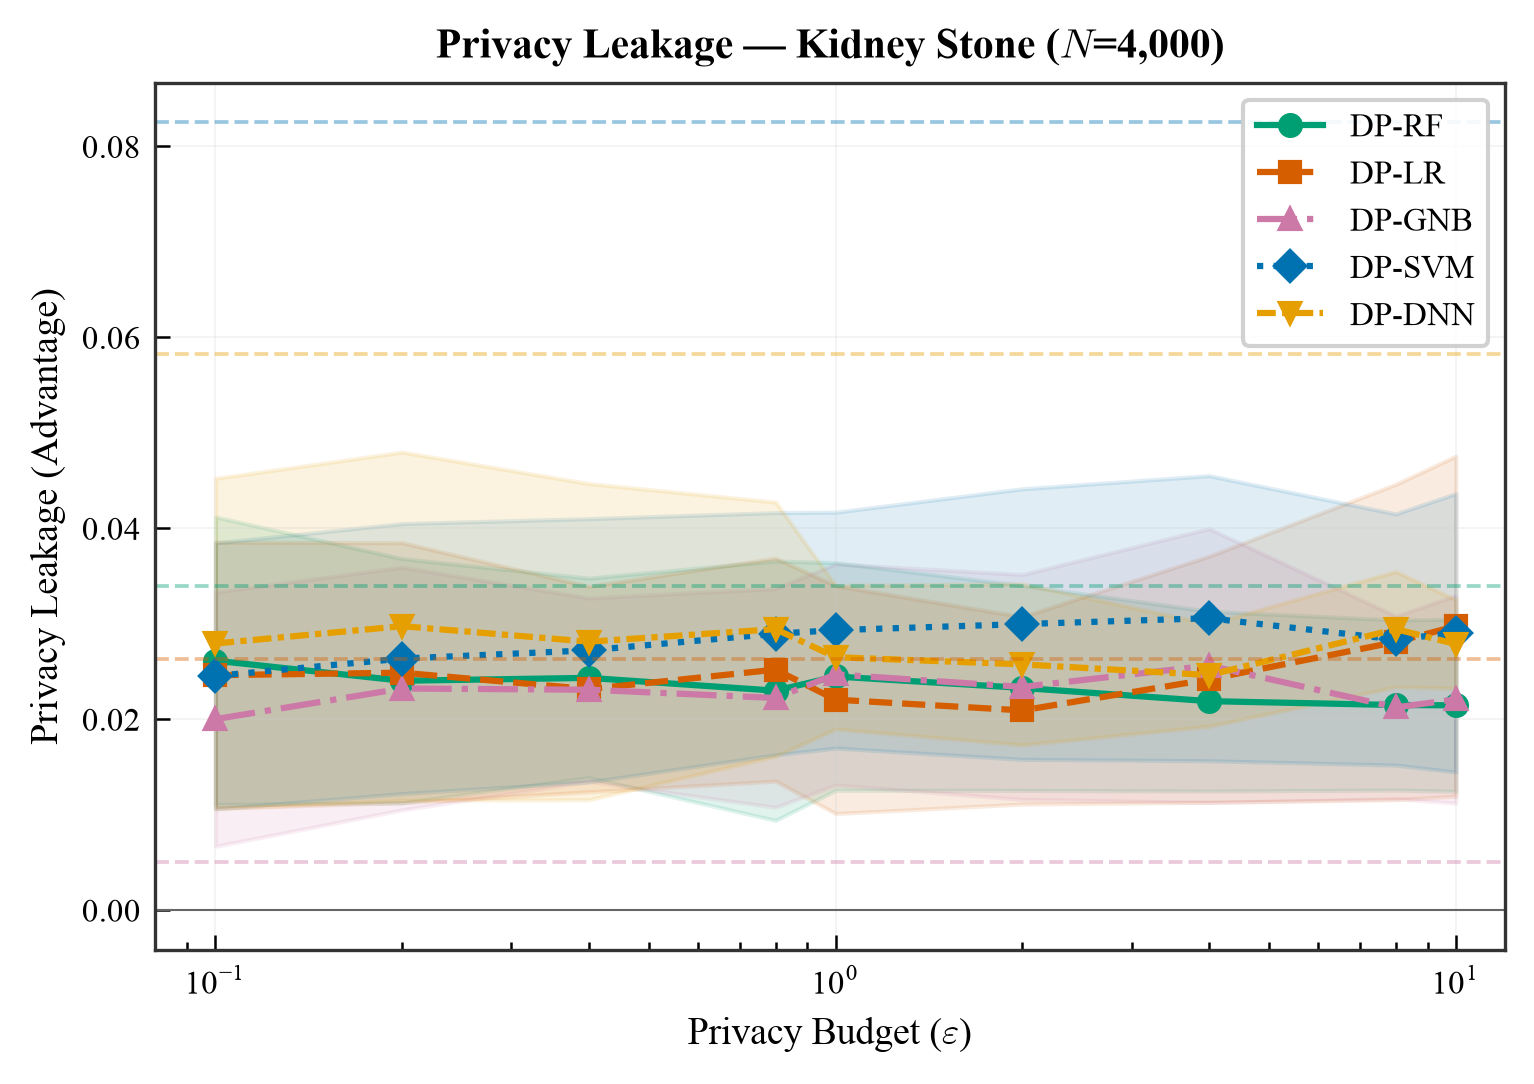

Saved: fig1_kidney_stone_privacy_leakage.pdf / .png


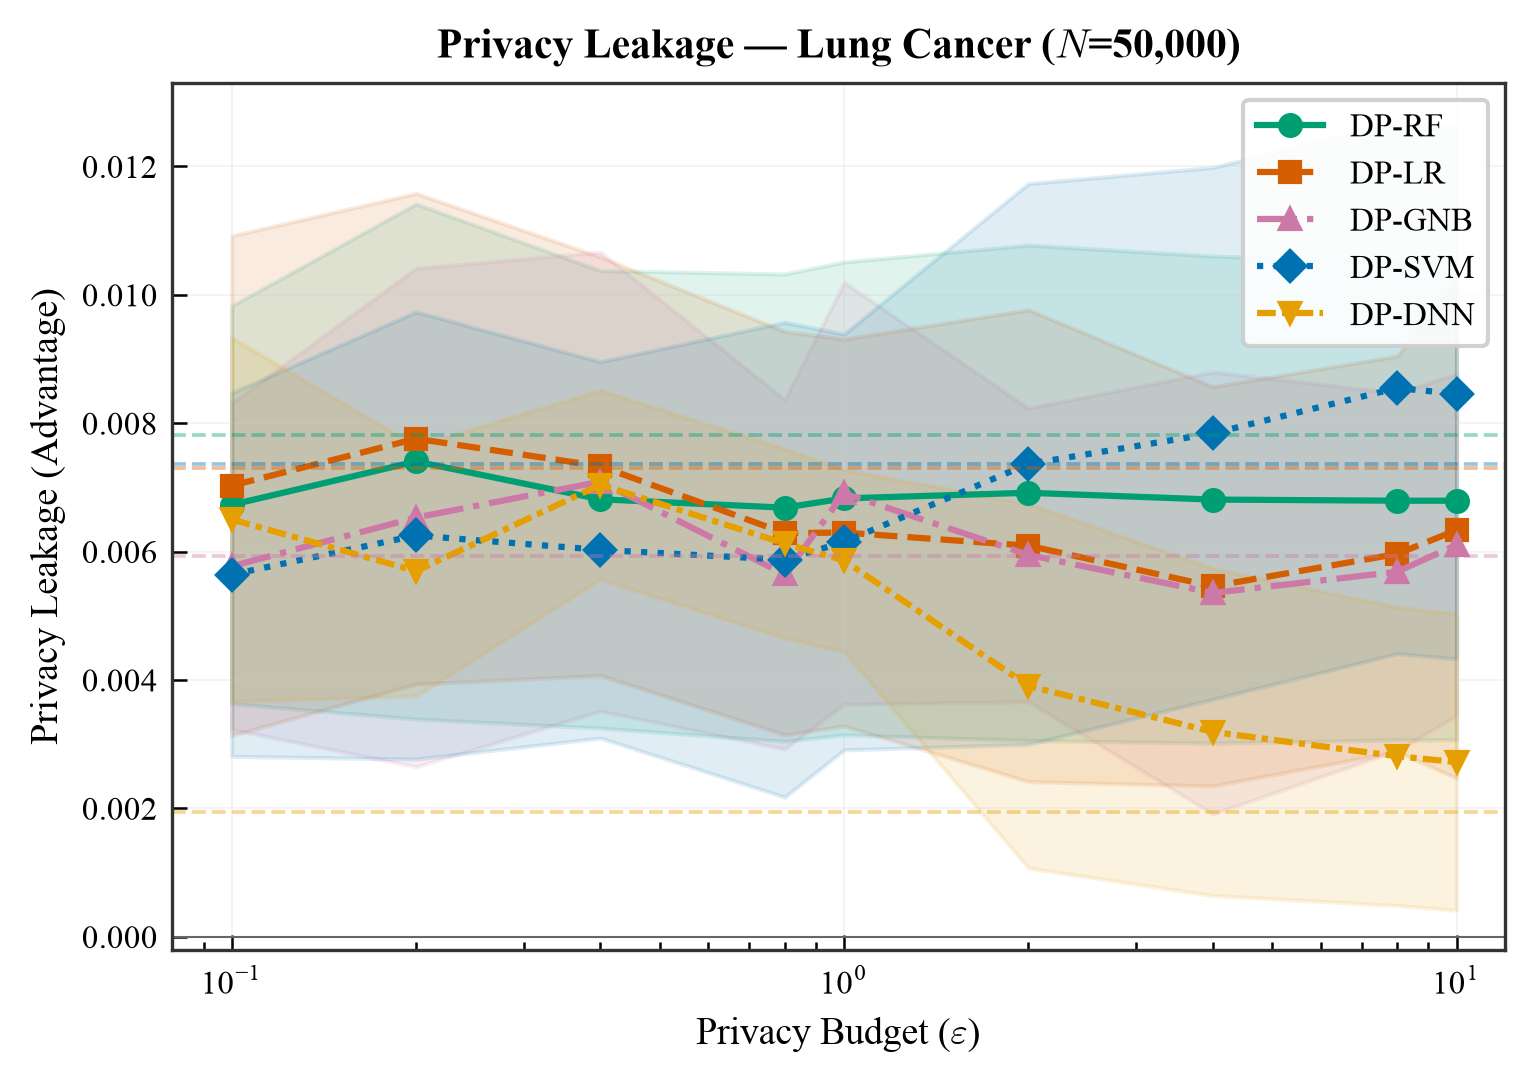

Saved: fig1_lung_cancer_privacy_leakage.pdf / .png


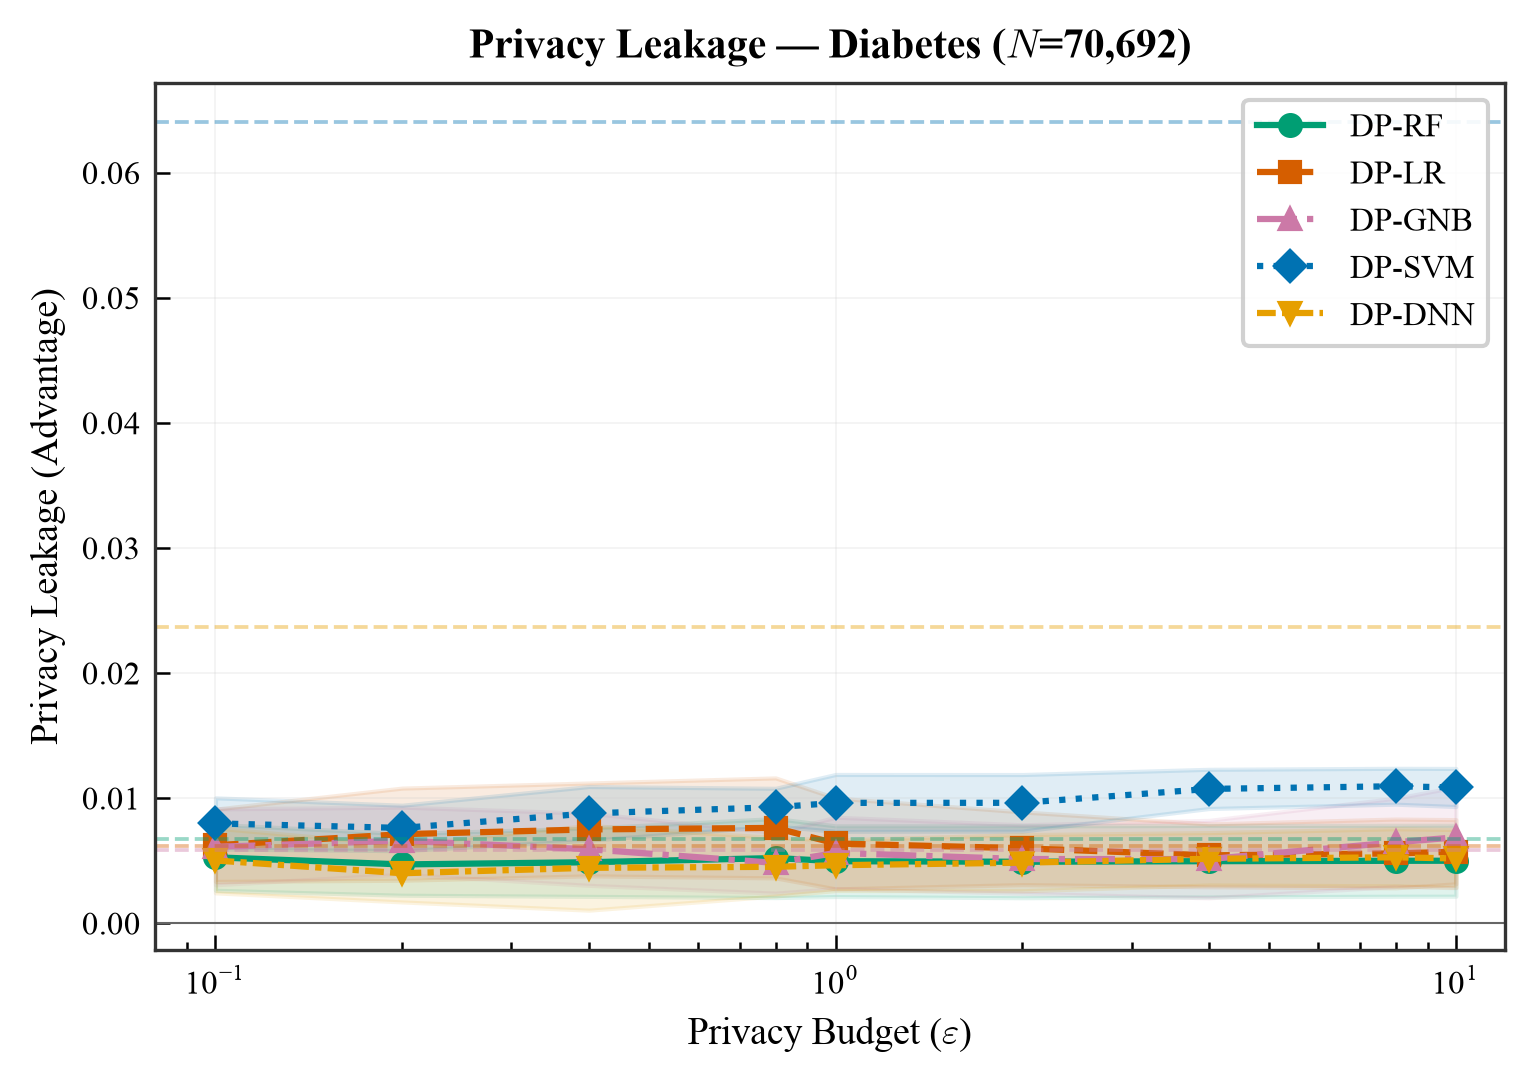

Saved: fig1_diabetes_privacy_leakage.pdf / .png


In [4]:
for dataset in DATASETS_ORDER:
    fig, ax = plt.subplots(figsize=(5.0, 3.5))
    
    ds_dp = df_dp[df_dp['dataset'] == dataset]
    ds_base = df_baseline[df_baseline['dataset'] == dataset]
    
    for model in MODELS_ORDER:
        m_data = ds_dp[ds_dp['model'] == model].sort_values('epsilon')
        if m_data.empty:
            continue
        ax.plot(
            m_data['epsilon'], m_data['advantage_mean'],
            color=MODEL_COLORS[model],
            marker=MODEL_MARKERS[model],
            linestyle=MODEL_LINESTYLES[model],
            markersize=5, linewidth=1.5, label=model
        )
        ax.fill_between(
            m_data['epsilon'],
            m_data['advantage_mean'] - m_data['advantage_std'],
            m_data['advantage_mean'] + m_data['advantage_std'],
            alpha=0.12, color=MODEL_COLORS[model]
        )
    
    # Baseline horizontal lines
    for _, row in ds_base.iterrows():
        dp_eq = row['dp_equivalent']
        if dp_eq in MODEL_COLORS:
            ax.axhline(
                row['advantage_mean'], color=MODEL_COLORS[dp_eq],
                linestyle='--', alpha=0.4, linewidth=0.9
            )
    
    n = DATASET_SIZES.get(dataset, 0)
    ax.set_title(f'Privacy Leakage — {dataset} ($N$={n:,})', fontsize=10, fontweight='bold')
    ax.set_xlabel(r'Privacy Budget ($\varepsilon$)', fontsize=9)
    ax.set_ylabel('Privacy Leakage (Advantage)', fontsize=9)
    ax.set_xscale('log')
    ax.set_xlim(0.08, 12)
    ax.grid(True, alpha=0.25, linestyle='-', color='#cccccc')
    ax.axhline(0, color='#666666', linewidth=0.5, linestyle='-')
    ax.legend(loc='best', fontsize=8, handlelength=2.0, framealpha=0.9)
    
    # Save
    safe_name = dataset.lower().replace(' ', '_')
    plt.savefig(GRAPH_DIR / f'{ATTACK}_fig1_{safe_name}_privacy_leakage.pdf', format='pdf', bbox_inches='tight')
    plt.savefig(GRAPH_DIR / f'{ATTACK}_fig1_{safe_name}_privacy_leakage.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: fig1_{safe_name}_privacy_leakage.pdf / .png")

---
## Figure 2: Privacy Leakage Reduction — Lollipop Chart

Clean comparison showing how much DP reduces privacy leakage relative to standard models at ε=1.0. Each dot-line pair shows the drop from standard → DP.

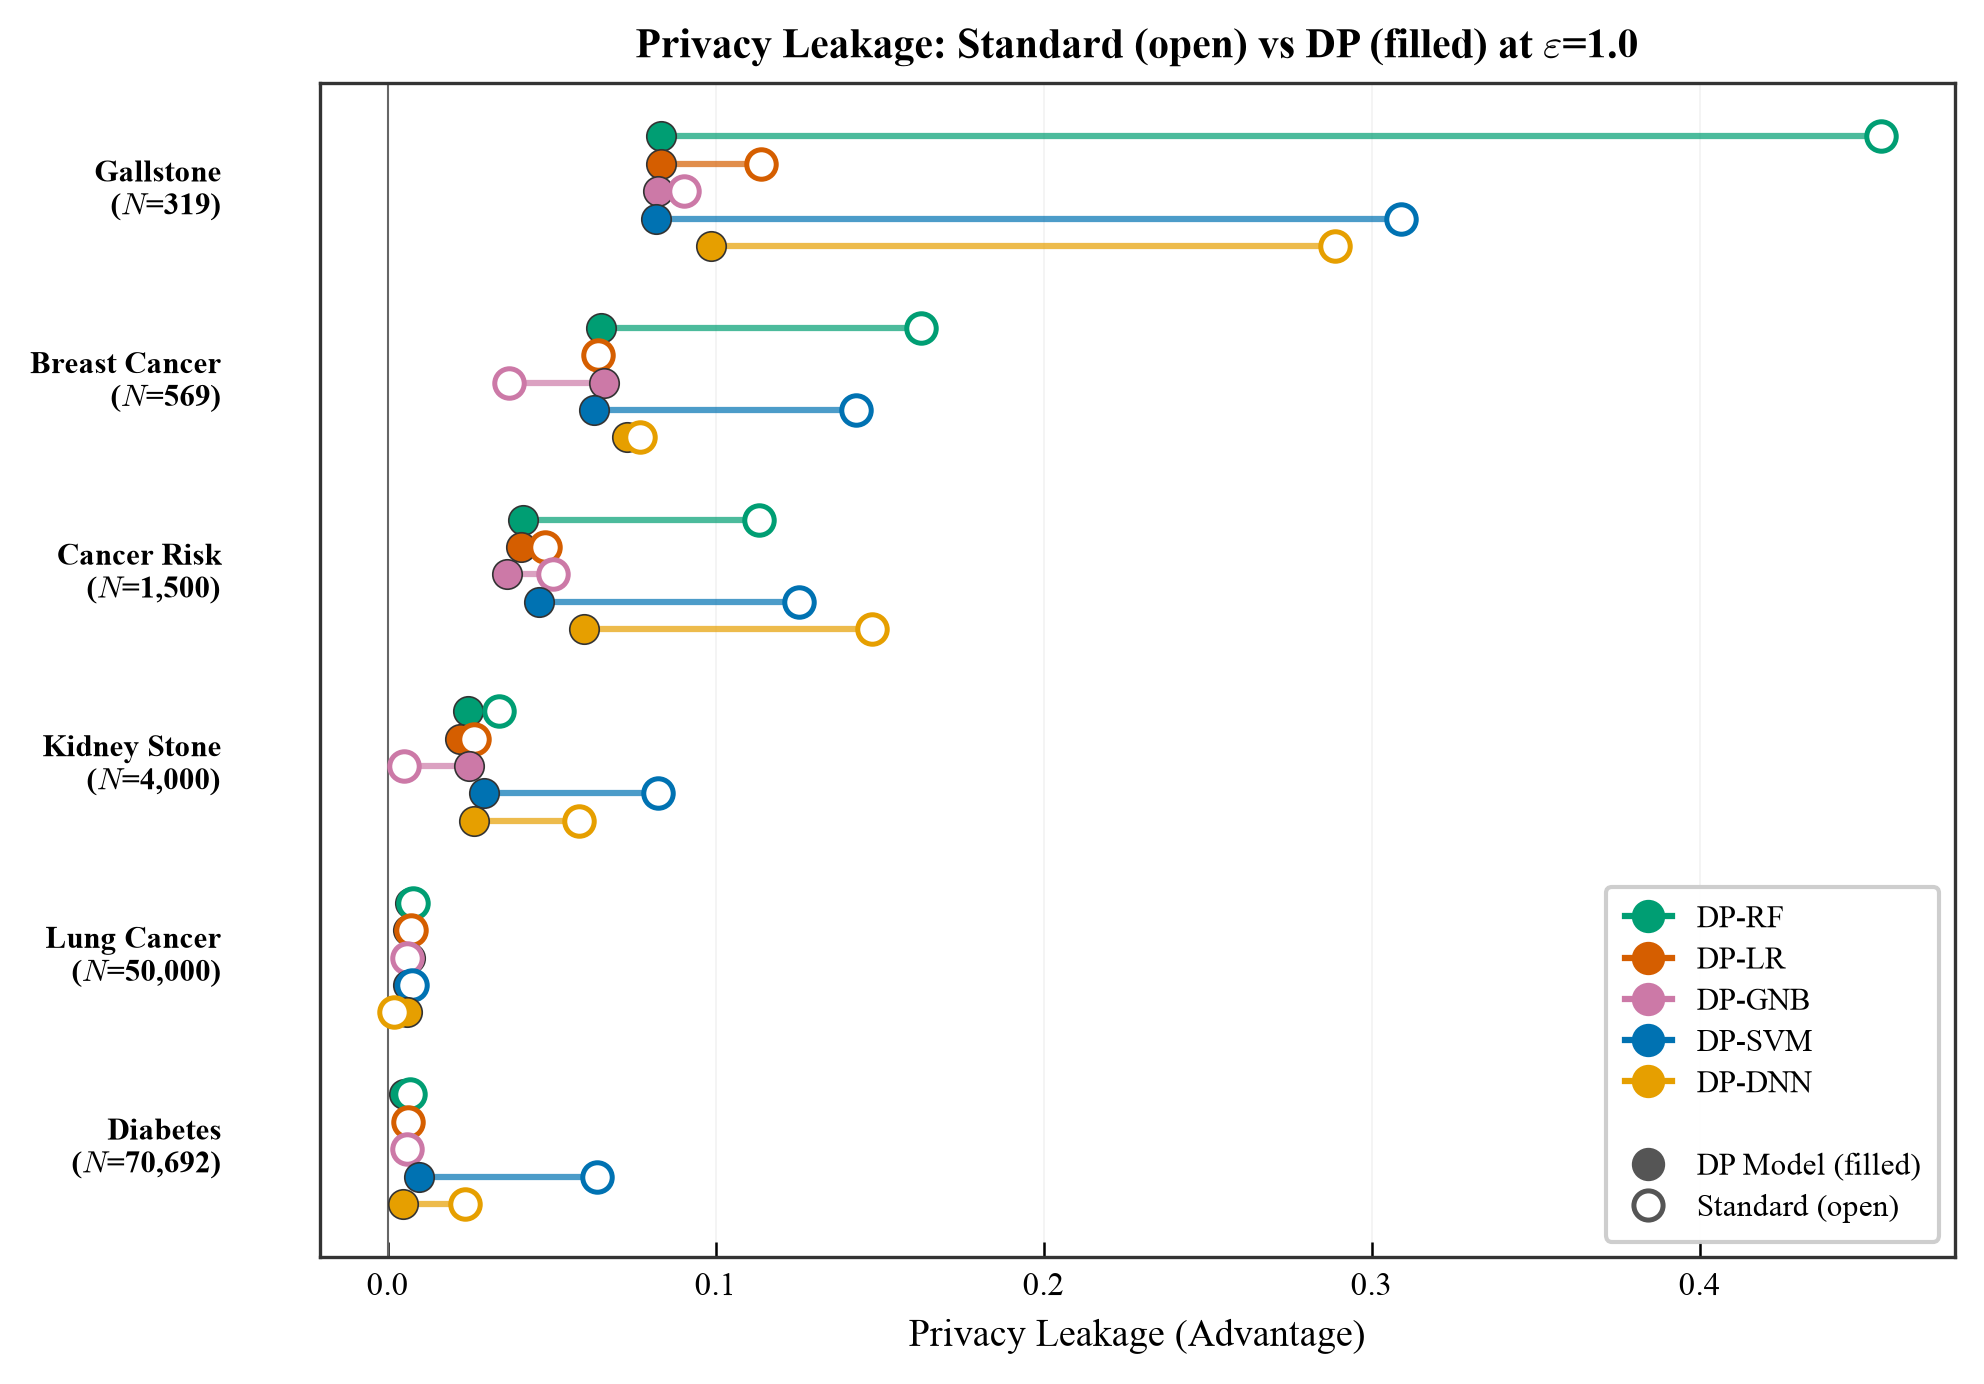

Saved: fig2_privacy_leakage_lollipop.pdf / .png


In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))

eps_target = 1.0
dp_at_eps = df_dp[df_dp['epsilon'] == eps_target]

y_pos = 0
positions = []
spacing = 0.6
group_gap = 1.2

for dataset in DATASETS_ORDER:
    for model in MODELS_ORDER:
        std_model = model.replace('DP-', 'Standard ')
        std_row = df_baseline[(df_baseline['model'] == std_model) & (df_baseline['dataset'] == dataset)]
        dp_row = dp_at_eps[(dp_at_eps['model'] == model) & (dp_at_eps['dataset'] == dataset)]

        if std_row.empty or dp_row.empty:
            continue

        std_val = std_row['advantage_mean'].values[0]
        dp_val = dp_row['advantage_mean'].values[0]

        # Draw lollipop: line from DP to Standard
        ax.plot([dp_val, std_val], [y_pos, y_pos],
                color=MODEL_COLORS[model], linewidth=1.5, alpha=0.7)
        # DP value (solid circle)
        ax.scatter(dp_val, y_pos, color=MODEL_COLORS[model],
                  s=50, zorder=5, edgecolors='#333333', linewidth=0.4)
        # Standard value (open circle)
        ax.scatter(std_val, y_pos, color=MODEL_COLORS[model],
                  s=50, zorder=5, edgecolors=MODEL_COLORS[model],
                  facecolors='white', linewidth=1.2)

        positions.append(y_pos)
        y_pos += spacing
    y_pos += group_gap

# Y-axis: only dataset group labels (no model names)
ax.set_yticks(positions)
ax.set_yticklabels([''] * len(positions))
ax.tick_params(axis='y', length=0)

y_pos_reset = 0
for dataset in DATASETS_ORDER:
    n_models_in_ds = len([m for m in MODELS_ORDER
                         if not df_baseline[(df_baseline['model'] == m.replace('DP-','Standard ')) &
                                           (df_baseline['dataset'] == dataset)].empty])
    if n_models_in_ds == 0:
        continue
    mid = y_pos_reset + (n_models_in_ds - 1) * spacing / 2
    n = DATASET_SIZES.get(dataset, 0)
    ax.text(-0.06, mid,
            f"{dataset}\n($N$={n:,})", va='center', ha='right',
            fontsize=7.5, fontweight='bold', transform=ax.get_yaxis_transform())
    y_pos_reset += n_models_in_ds * spacing + group_gap

ax.set_xlabel('Privacy Leakage (Advantage)', fontsize=9)
ax.set_title(r'Privacy Leakage: Standard (open) vs DP (filled) at $\varepsilon$=1.0',
             fontweight='bold', fontsize=10)
ax.axvline(0, color='#666666', linewidth=0.5)
ax.grid(True, axis='x', alpha=0.25, linestyle='-', color='#cccccc')
ax.invert_yaxis()

# Combined legend at bottom right: model colors + marker type
legend_elements = [
    plt.Line2D([0], [0], marker='o', color=MODEL_COLORS[m], markerfacecolor=MODEL_COLORS[m],
              markersize=7, linewidth=1.5, label=m) for m in MODELS_ORDER
]
legend_elements.append(plt.Line2D([], [], linewidth=0, label=''))  # spacer
legend_elements.append(
    plt.Line2D([0], [0], marker='o', color='#555555', markerfacecolor='#555555',
              markersize=7, linewidth=0, label='DP Model (filled)')
)
legend_elements.append(
    plt.Line2D([0], [0], marker='o', color='#555555', markerfacecolor='white',
              markeredgecolor='#555555', markersize=7, markeredgewidth=1.2,
              linewidth=0, label='Standard (open)')
)
ax.legend(handles=legend_elements, loc='lower right', fontsize=7.5,
          framealpha=0.95, edgecolor='#cccccc', handlelength=1.5,
          borderpad=0.6, labelspacing=0.4)

plt.savefig(GRAPH_DIR / f'{ATTACK}_fig2_privacy_leakage_lollipop.pdf', format='pdf', bbox_inches='tight')
plt.savefig(GRAPH_DIR / f'{ATTACK}_fig2_privacy_leakage_lollipop.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig2_privacy_leakage_lollipop.pdf / .png")

---
## Figures 3a–3e: Privacy Leakage by Model (One per Model, Lines = Datasets)

Each plot shows one model's privacy leakage across all datasets. Dashed lines = standard baselines.

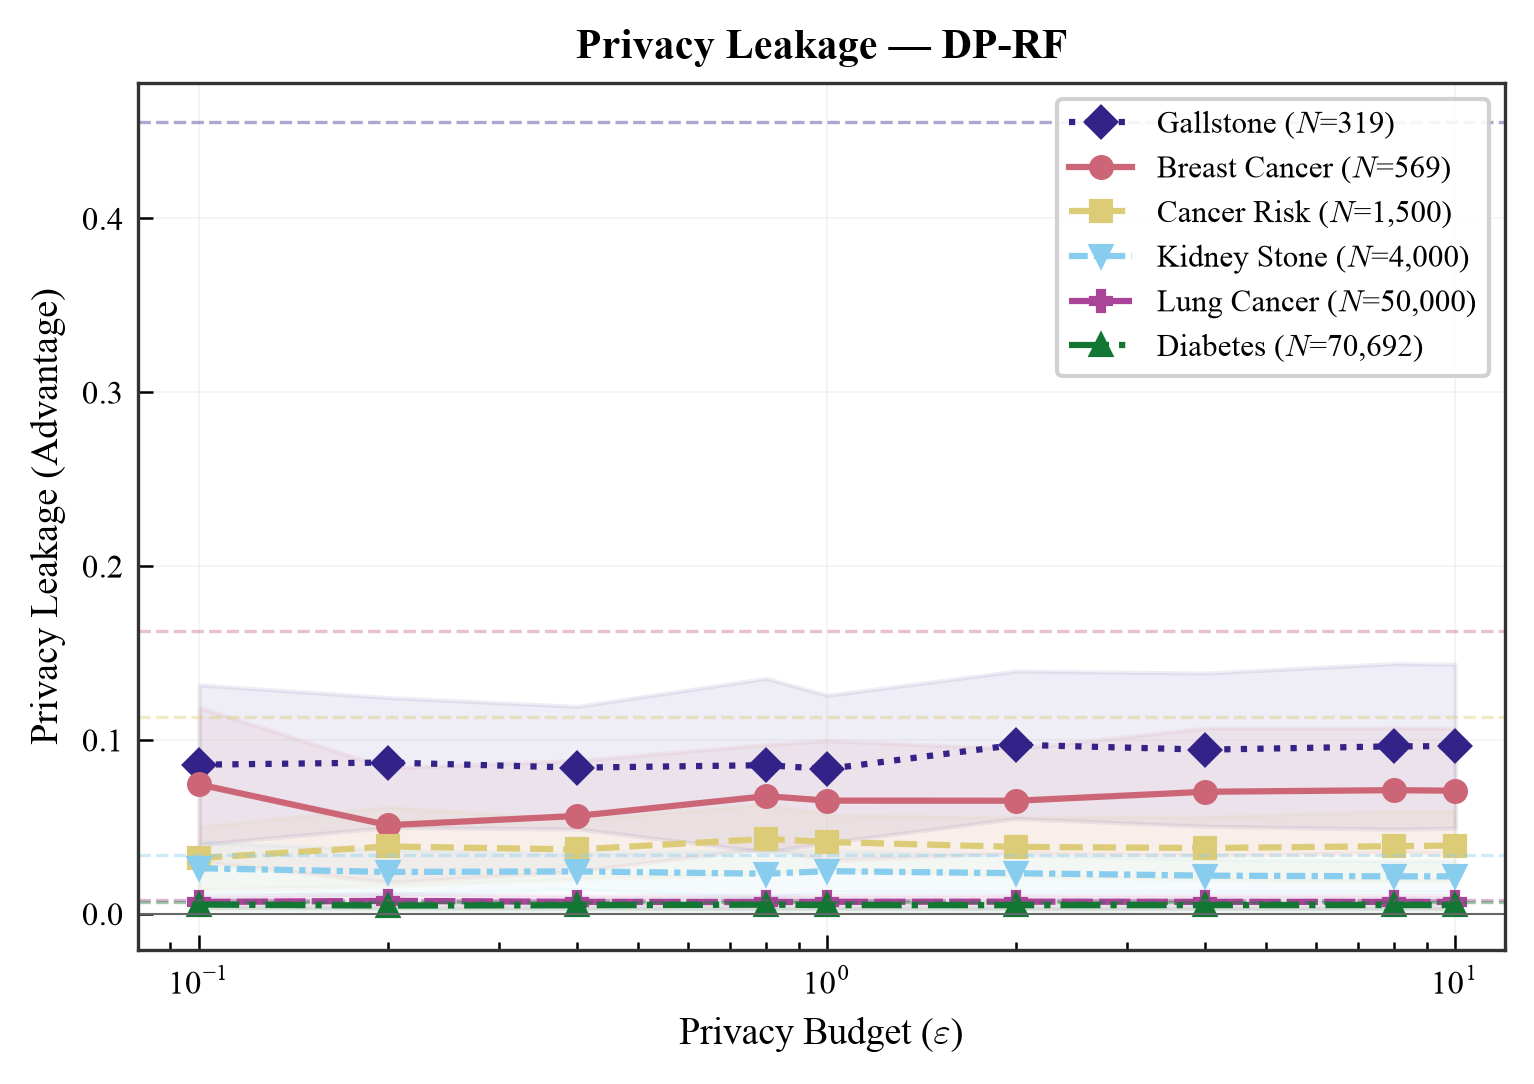

Saved: fig3_dp_rf_privacy_leakage.pdf / .png


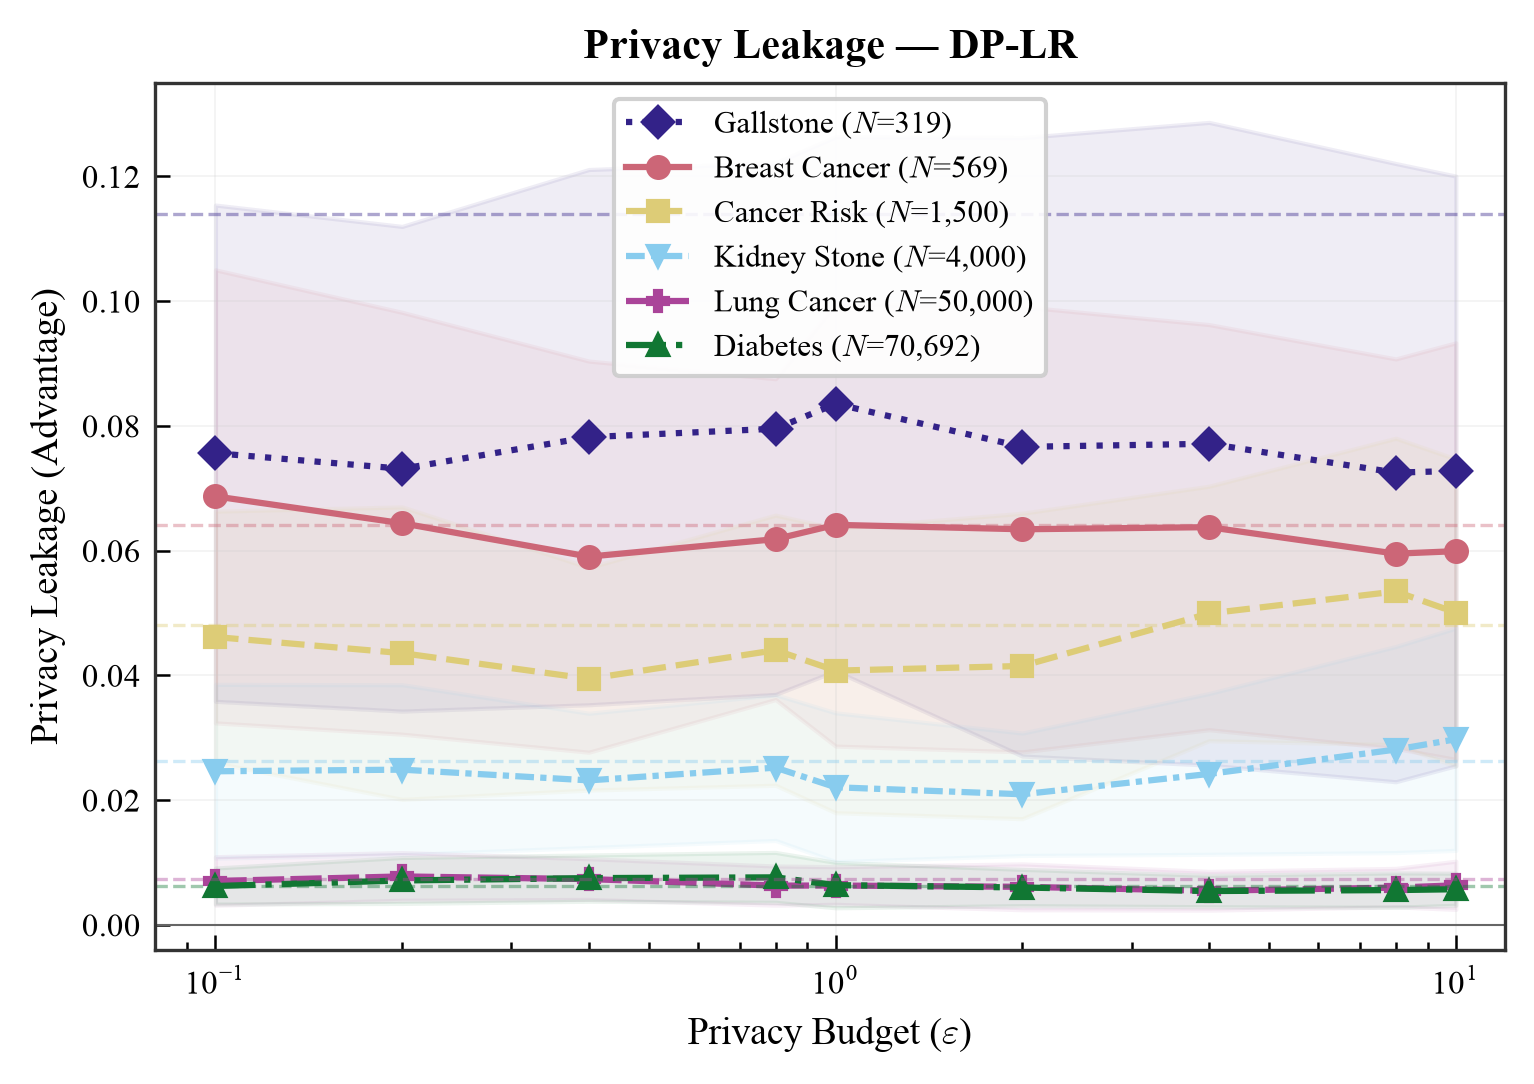

Saved: fig3_dp_lr_privacy_leakage.pdf / .png


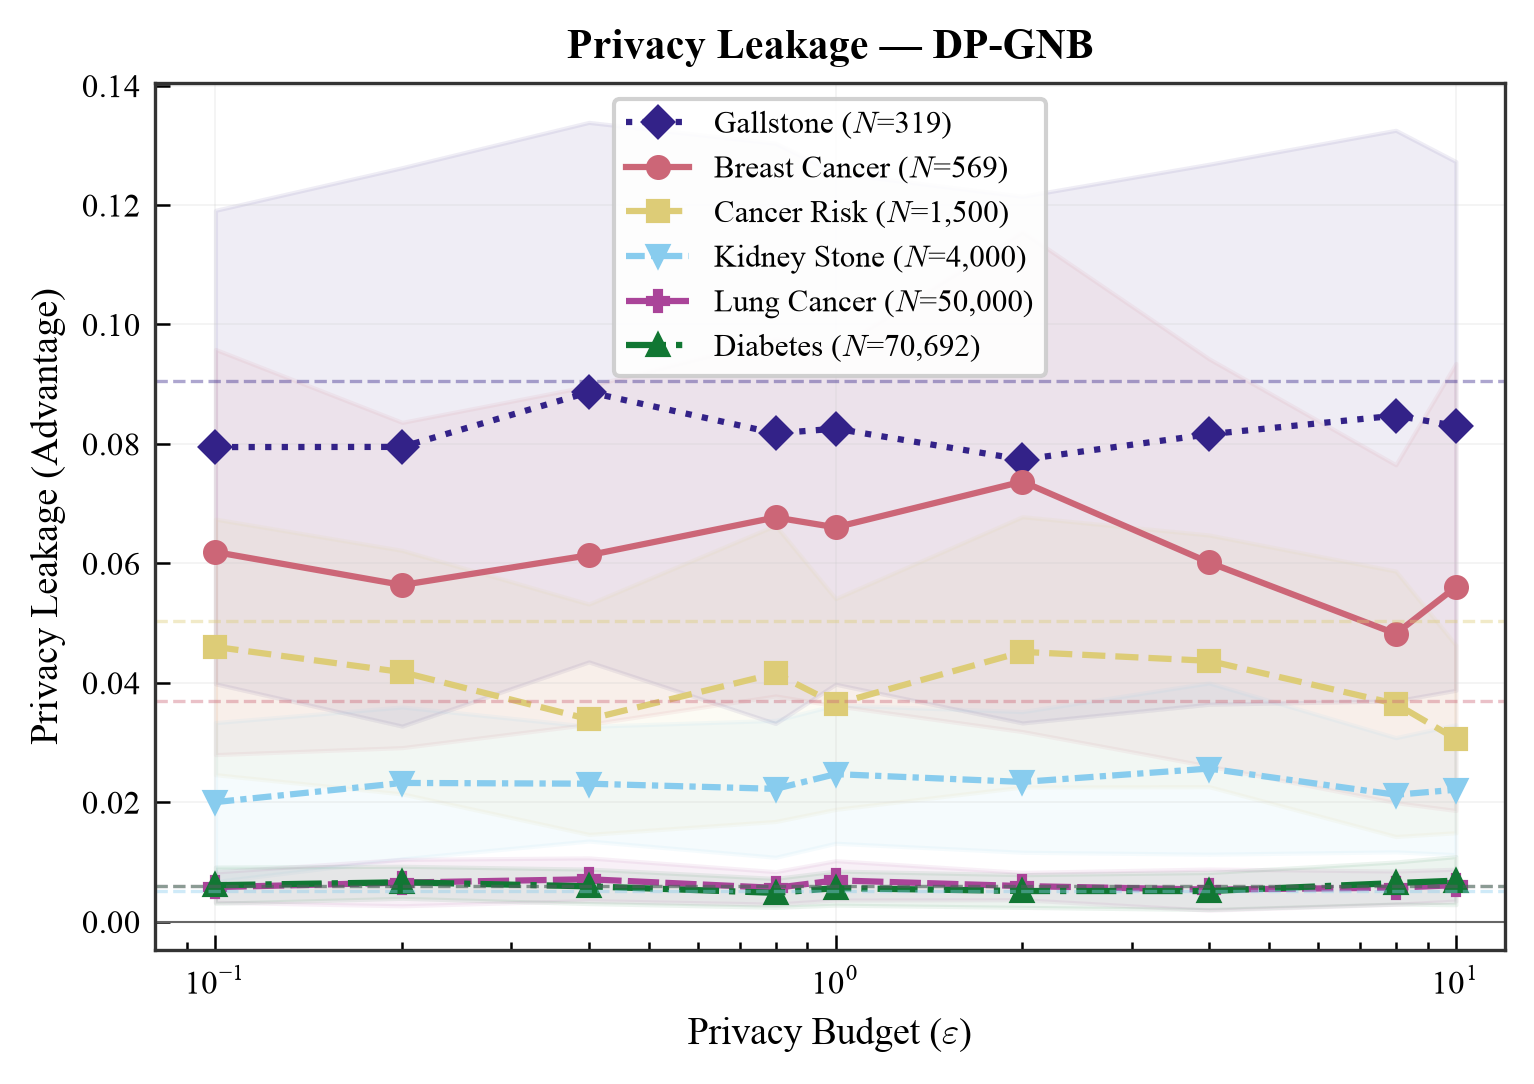

Saved: fig3_dp_gnb_privacy_leakage.pdf / .png


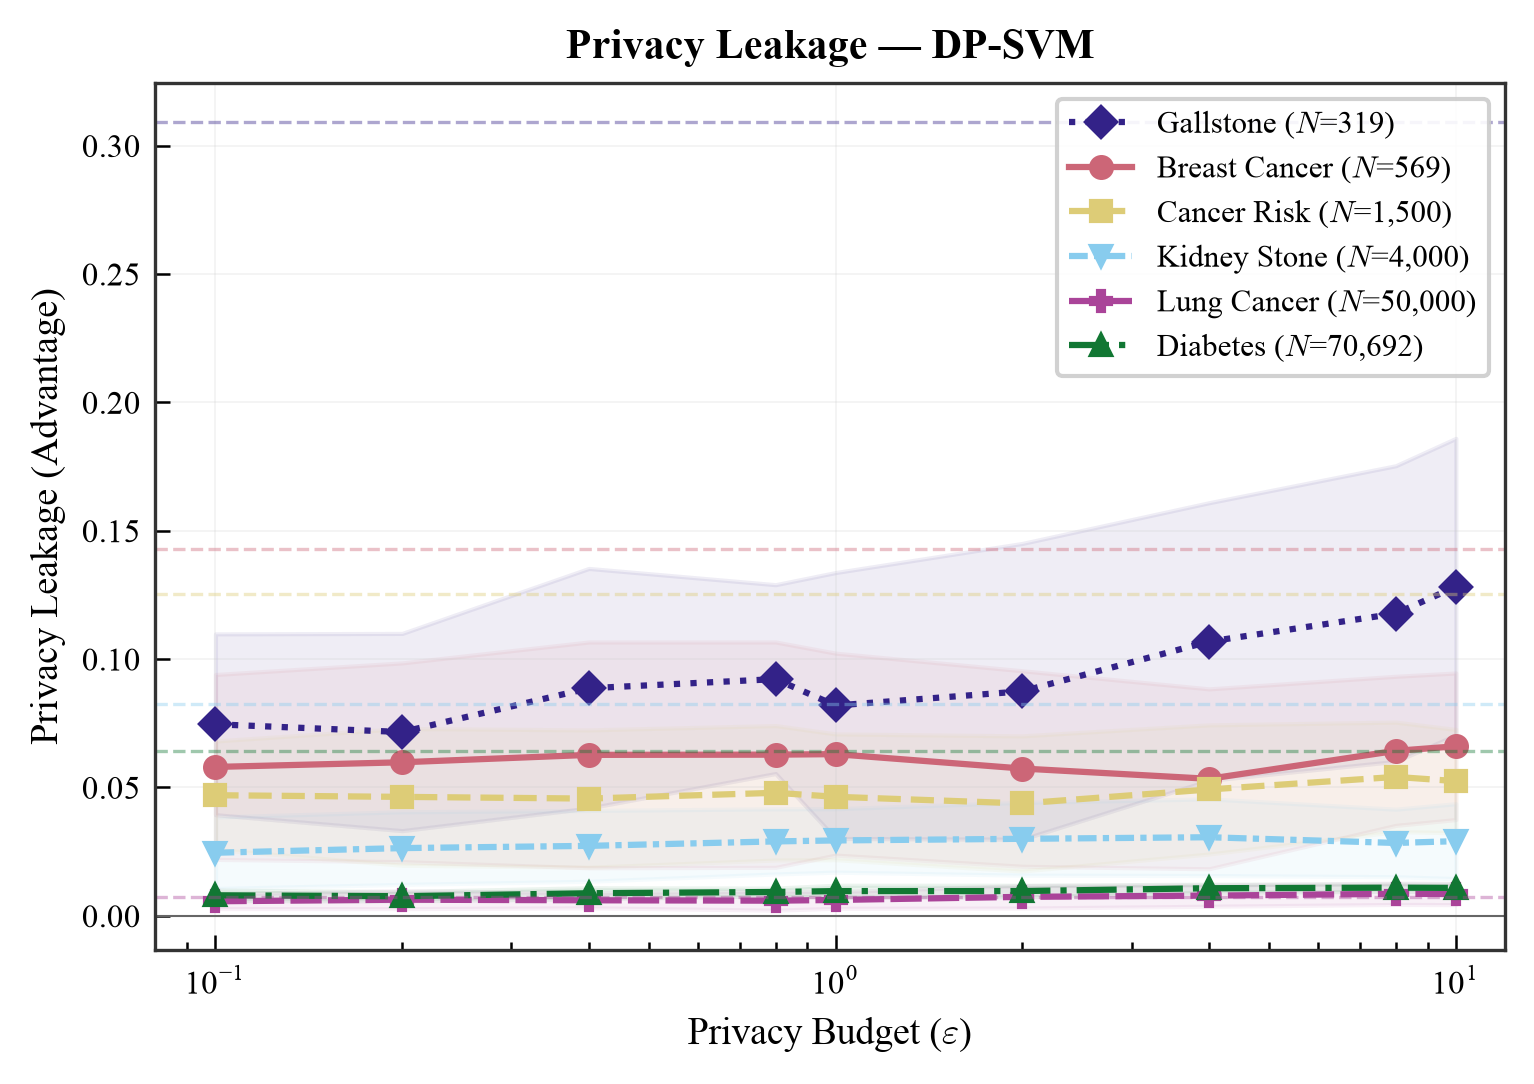

Saved: fig3_dp_svm_privacy_leakage.pdf / .png


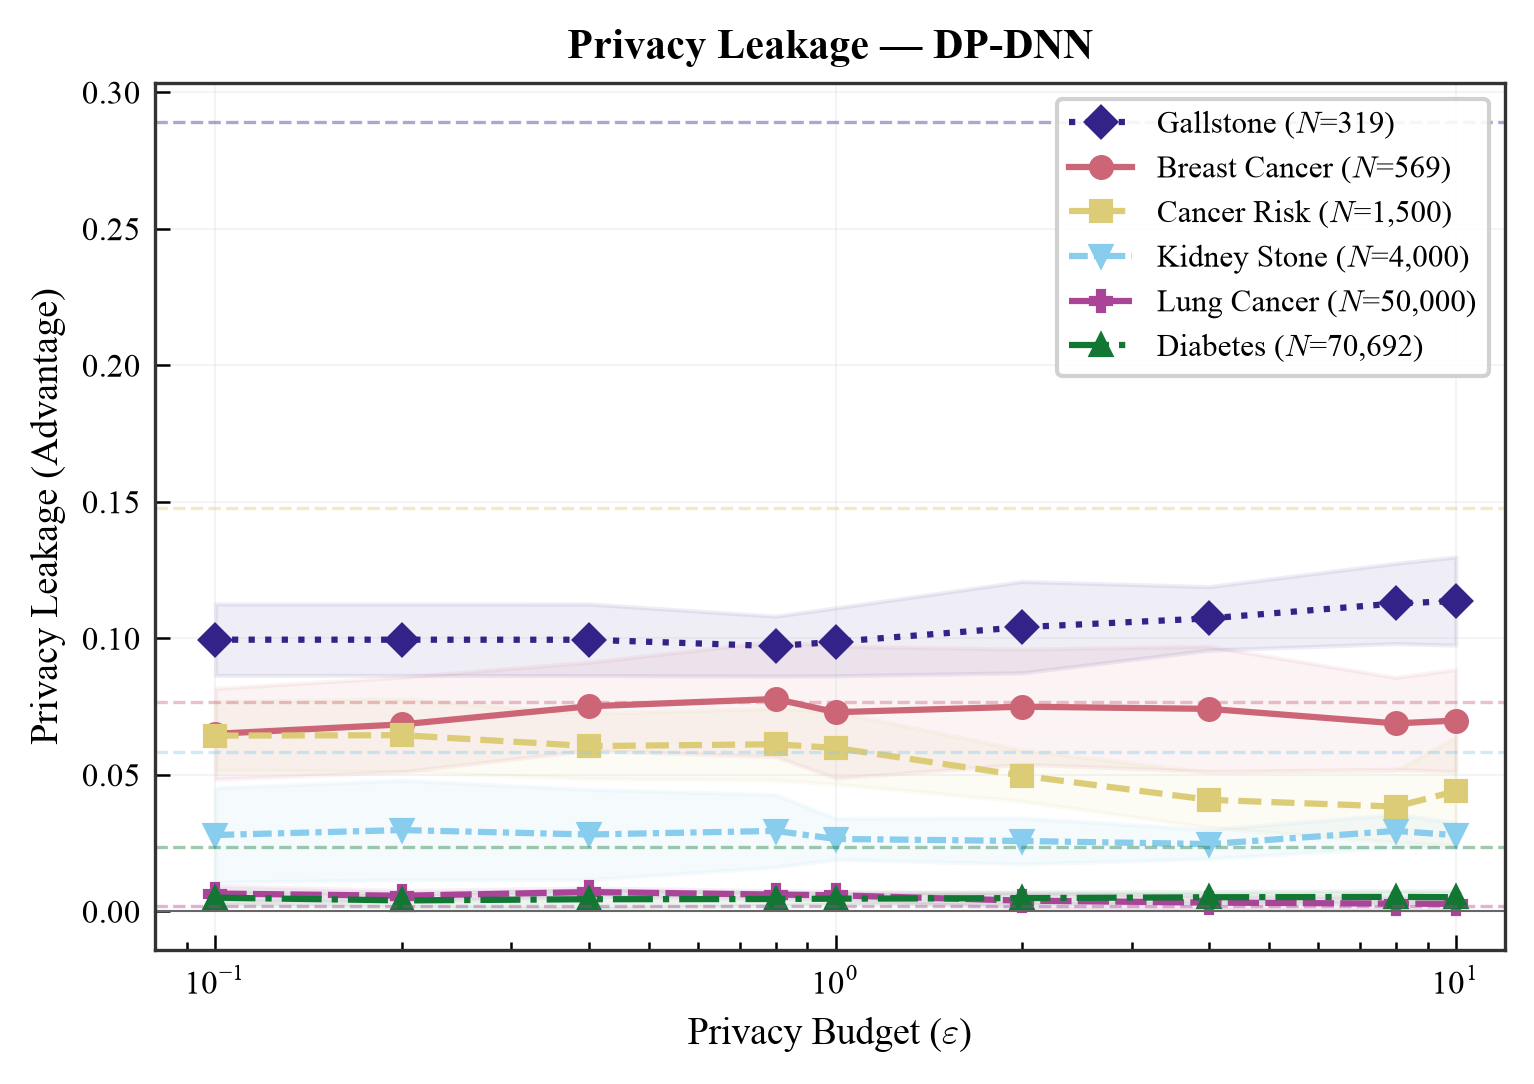

Saved: fig3_dp_dnn_privacy_leakage.pdf / .png


In [6]:
for model in MODELS_ORDER:
    fig, ax = plt.subplots(figsize=(5.0, 3.5))
    
    model_data = df_dp[df_dp['model'] == model]
    
    for dataset in DATASETS_ORDER:
        ds_data = model_data[model_data['dataset'] == dataset].sort_values('epsilon')
        if ds_data.empty:
            continue
        n = DATASET_SIZES.get(dataset, 0)
        ax.plot(
            ds_data['epsilon'], ds_data['advantage_mean'],
            color=DATASET_COLORS[dataset],
            linestyle=DATASET_LINESTYLES[dataset],
            marker=DATASET_MARKERS[dataset],
            markersize=5, linewidth=1.5,
            label=f"{dataset} ($N$={n:,})"
        )
        ax.fill_between(
            ds_data['epsilon'],
            ds_data['advantage_mean'] - ds_data['advantage_std'],
            ds_data['advantage_mean'] + ds_data['advantage_std'],
            alpha=0.08, color=DATASET_COLORS[dataset]
        )
    
    # Baseline for this model per dataset
    for dataset in DATASETS_ORDER:
        base_row = df_baseline[(df_baseline['dp_equivalent'] == model) & (df_baseline['dataset'] == dataset)]
        if not base_row.empty:
            ax.axhline(base_row['advantage_mean'].values[0],
                      color=DATASET_COLORS[dataset], linestyle='--', alpha=0.4, linewidth=0.8)
    
    ax.set_title(f'Privacy Leakage — {model}', fontweight='bold', fontsize=10)
    ax.set_xlabel(r'Privacy Budget ($\varepsilon$)', fontsize=9)
    ax.set_ylabel('Privacy Leakage (Advantage)', fontsize=9)
    ax.set_xscale('log')
    ax.set_xlim(0.08, 12)
    ax.grid(True, alpha=0.25, linestyle='-', color='#cccccc')
    ax.axhline(0, color='#666666', linewidth=0.5)
    ax.legend(loc='best', fontsize=7.5, handlelength=2.0, framealpha=0.9)
    
    safe_name = model.lower().replace('-', '_')
    plt.savefig(GRAPH_DIR / f'{ATTACK}_fig3_{safe_name}_privacy_leakage.pdf', format='pdf', bbox_inches='tight')
    plt.savefig(GRAPH_DIR / f'{ATTACK}_fig3_{safe_name}_privacy_leakage.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: fig3_{safe_name}_privacy_leakage.pdf / .png")

---
## Figure 4: Privacy Leakage Summary Heatmap (DP vs Standard)

Side-by-side heatmaps comparing mean privacy leakage of DP models vs standard baselines across all datasets.

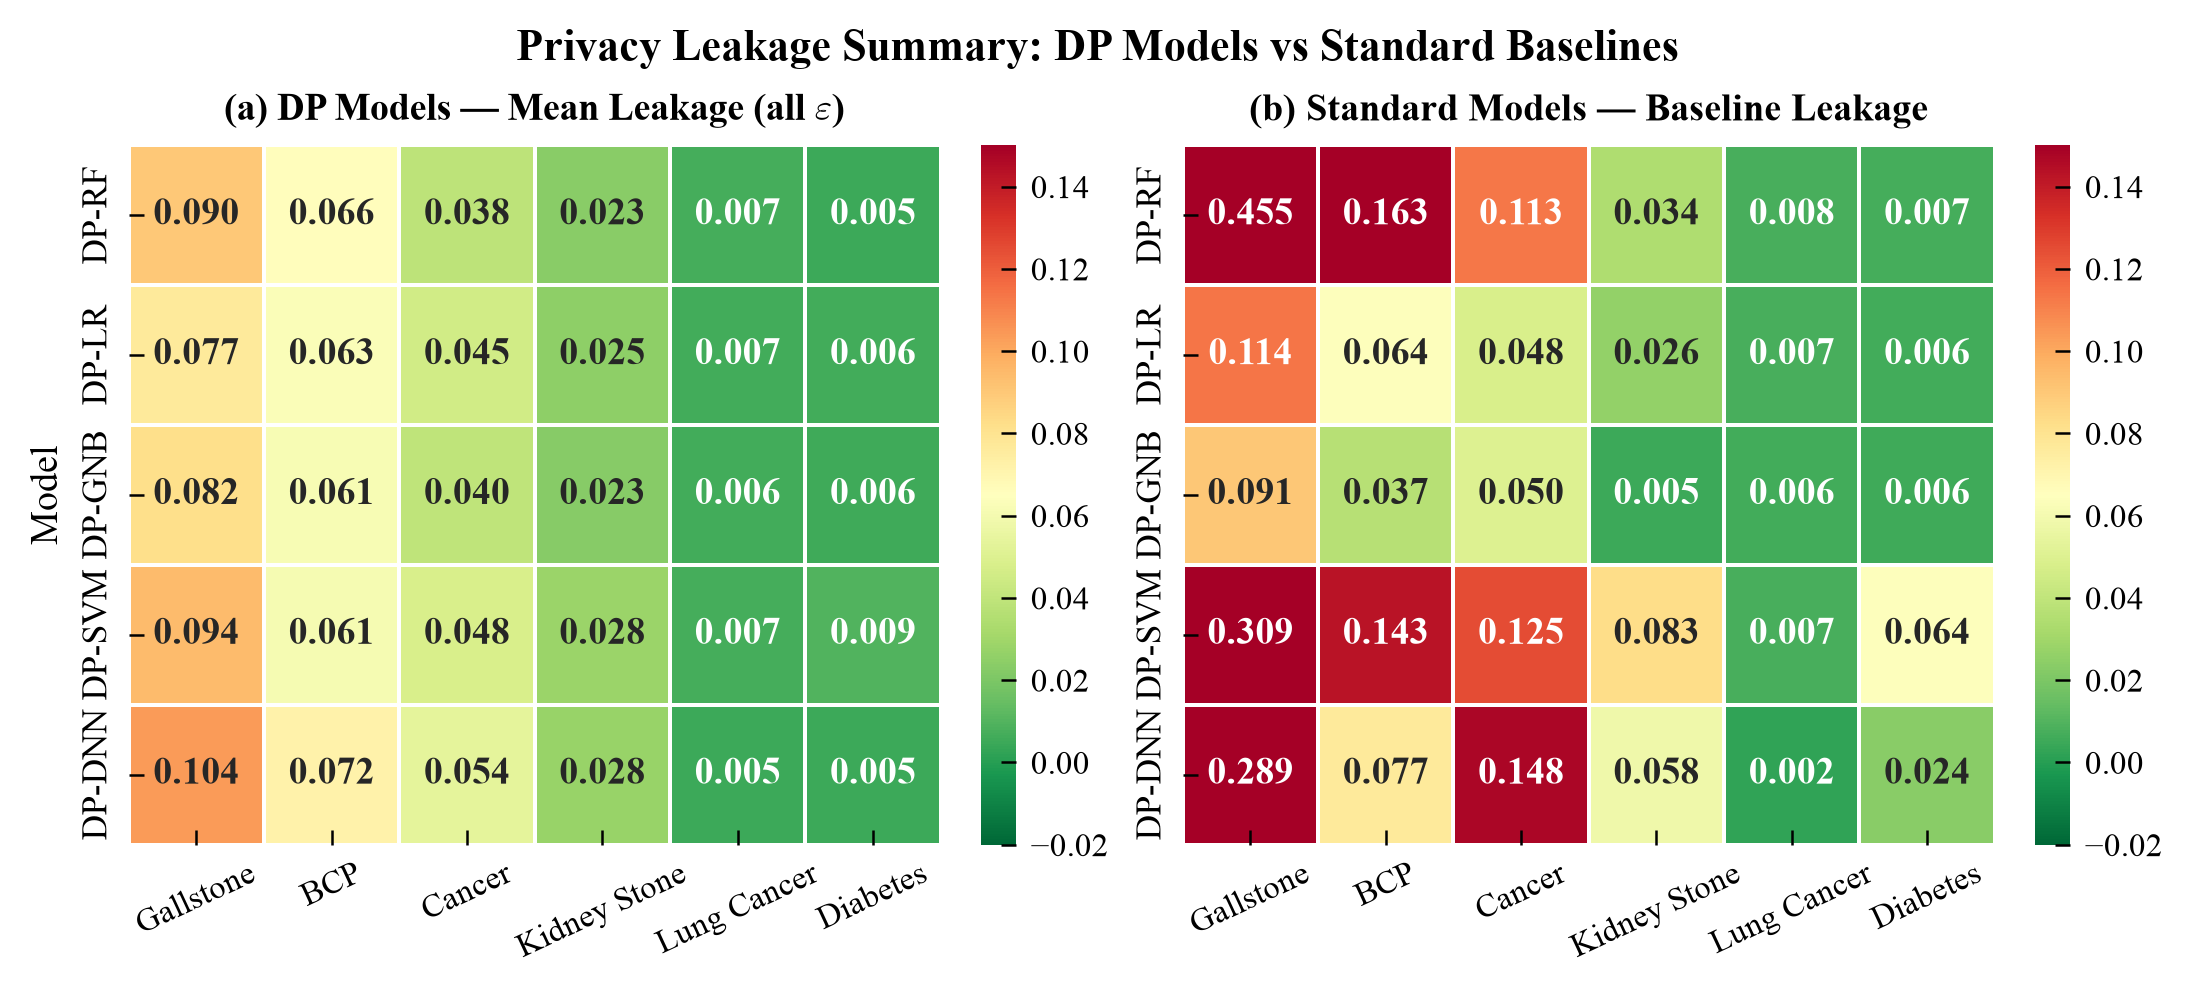

Saved: fig4_privacy_leakage_summary_heatmap.pdf / .png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2))

short_names = {'Breast Cancer': 'BCP', 'Cancer Risk': 'Cancer', 'Diabetes': 'Diabetes',
               'Gallstone': 'Gallstone', 'Kidney Stone': 'Kidney Stone', 'Lung Cancer': 'Lung Cancer'}

# Left: DP models average privacy leakage
ax = axes[0]
avg_adv_dp = df_dp.groupby(['model', 'dataset'])['advantage_mean'].mean().unstack()
avg_adv_dp = avg_adv_dp.reindex(index=[m for m in MODELS_ORDER if m in avg_adv_dp.index])
avg_adv_dp = avg_adv_dp.reindex(columns=[d for d in DATASETS_ORDER if d in avg_adv_dp.columns])
avg_adv_dp.columns = [short_names.get(c, c) for c in avg_adv_dp.columns]

sns.heatmap(
    avg_adv_dp, annot=True, fmt='.3f', cmap='RdYlGn_r',
    vmin=-0.02, vmax=0.15, ax=ax, linewidths=0.5, linecolor='white',
    annot_kws={'size': 9, 'weight': 'bold'}
)
ax.set_title(r'(a) DP Models — Mean Leakage (all $\varepsilon$)', fontweight='bold', fontsize=9)
ax.set_xlabel('')
ax.set_ylabel('Model', fontsize=9)
ax.tick_params(axis='x', rotation=25, labelsize=8)
ax.tick_params(axis='y', labelsize=8.5)

# Right: Standard baselines
ax = axes[1]
base_adv = df_baseline.copy()
base_adv['model_short'] = base_adv['dp_equivalent']
avg_adv_base = base_adv.groupby(['model_short', 'dataset'])['advantage_mean'].mean().unstack()
avg_adv_base = avg_adv_base.reindex(index=[m for m in MODELS_ORDER if m in avg_adv_base.index])
avg_adv_base = avg_adv_base.reindex(columns=[d for d in DATASETS_ORDER if d in avg_adv_base.columns])
avg_adv_base.columns = [short_names.get(c, c) for c in avg_adv_base.columns]

sns.heatmap(
    avg_adv_base, annot=True, fmt='.3f', cmap='RdYlGn_r',
    vmin=-0.02, vmax=0.15, ax=ax, linewidths=0.5, linecolor='white',
    annot_kws={'size': 9, 'weight': 'bold'}
)
ax.set_title('(b) Standard Models — Baseline Leakage', fontweight='bold', fontsize=9)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=25, labelsize=8)
ax.tick_params(axis='y', labelsize=8.5)

fig.suptitle('Privacy Leakage Summary: DP Models vs Standard Baselines',
             fontsize=10.5, fontweight='bold')

plt.savefig(GRAPH_DIR / f'{ATTACK}_fig4_privacy_leakage_summary_heatmap.pdf', format='pdf', bbox_inches='tight')
plt.savefig(GRAPH_DIR / f'{ATTACK}_fig4_privacy_leakage_summary_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig4_privacy_leakage_summary_heatmap.pdf / .png")

---
## Figure 5: Summary Statistics (Visual Table)

Key MIA statistics rendered as a publication-ready visual table graphic.

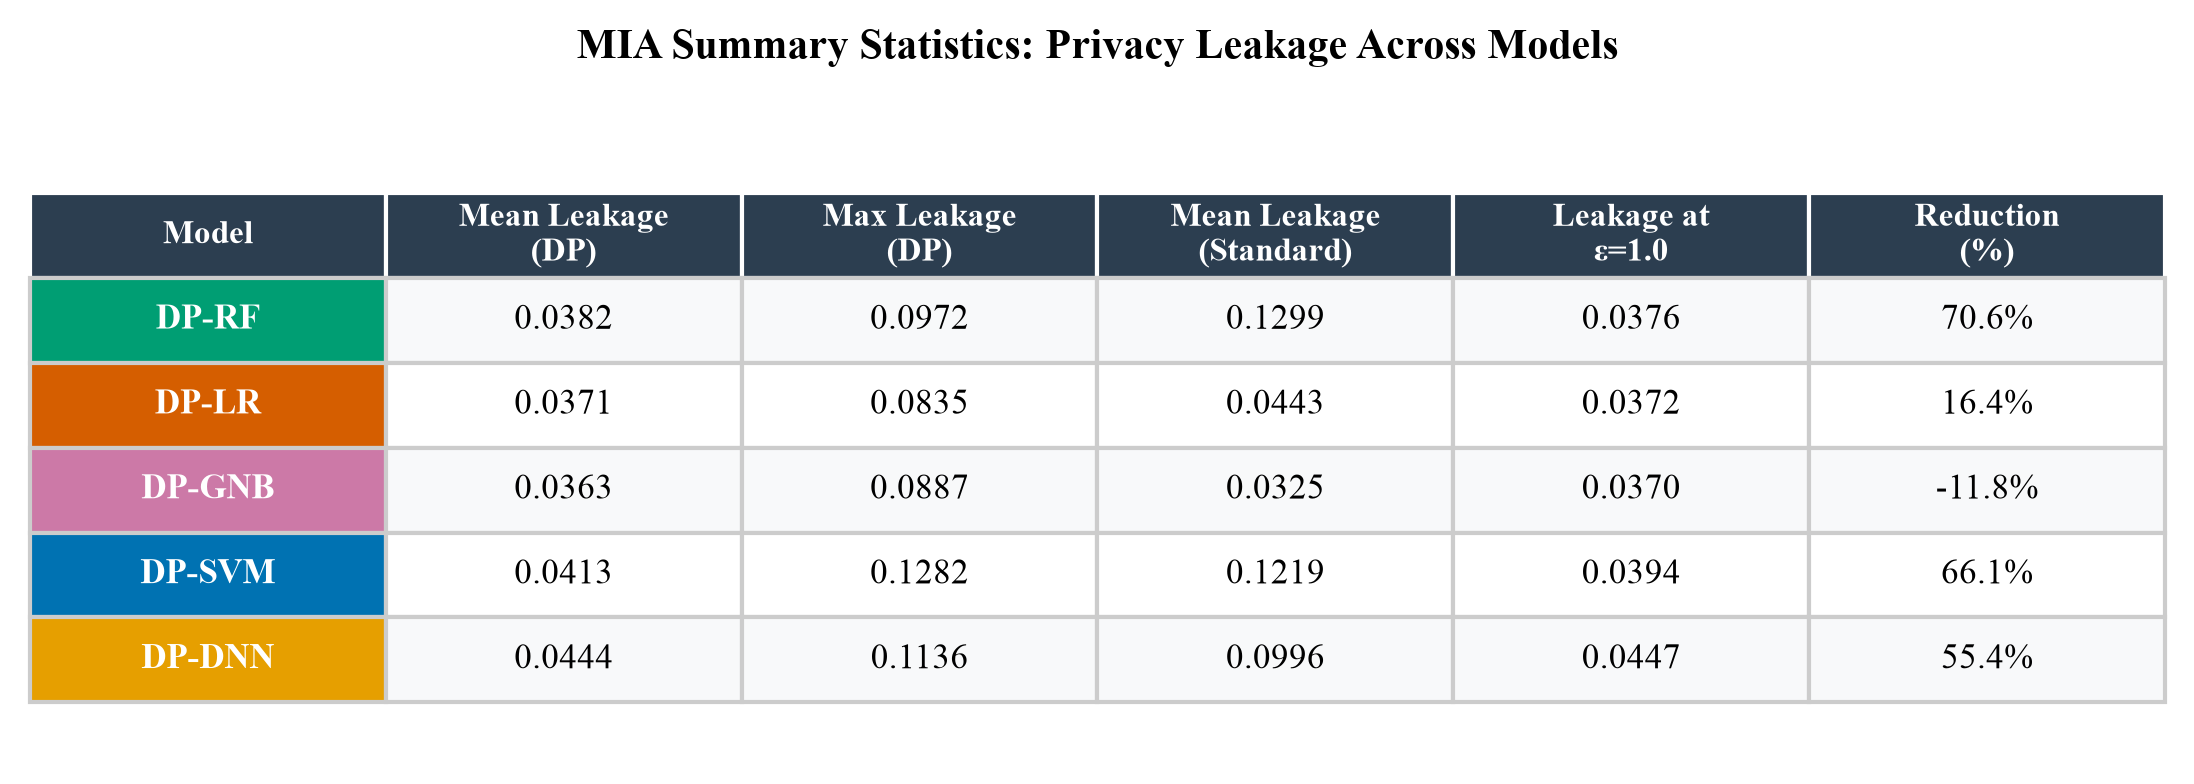

Saved: fig5_summary_statistics_table.pdf / .png


In [8]:
# Compute summary stats
summary_rows = []
for model in MODELS_ORDER:
    m_dp = df_dp[df_dp['model'] == model]
    std_model = model.replace('DP-', 'Standard ')
    m_base = df_baseline[df_baseline['model'] == std_model]
    
    mean_leakage_dp = m_dp['advantage_mean'].mean()
    max_leakage_dp = m_dp['advantage_mean'].max()
    mean_leakage_std = m_base['advantage_mean'].mean()
    
    # Reduction at eps=1.0
    dp_eps1 = m_dp[m_dp['epsilon'] == 1.0]['advantage_mean'].mean()
    reduction_pct = ((mean_leakage_std - mean_leakage_dp) / mean_leakage_std * 100) if mean_leakage_std > 0 else 0
    
    summary_rows.append({
        'Model': model,
        'Mean Leakage\n(DP)': f"{mean_leakage_dp:.4f}",
        'Max Leakage\n(DP)': f"{max_leakage_dp:.4f}",
        'Mean Leakage\n(Standard)': f"{mean_leakage_std:.4f}",
        'Leakage at\nε=1.0': f"{dp_eps1:.4f}",
        'Reduction\n(%)': f"{reduction_pct:.1f}%",
    })

df_summary = pd.DataFrame(summary_rows)

# Create visual table
fig, ax = plt.subplots(figsize=(7.2, 2.5))
ax.axis('off')

col_labels = list(df_summary.columns)
cell_text = df_summary.values.tolist()

table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc='center',
    loc='center'
)

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1.0, 1.6)

# Header styling
for j in range(len(col_labels)):
    cell = table[0, j]
    cell.set_facecolor('#2c3e50')
    cell.set_text_props(color='white', fontweight='bold', fontsize=8)
    cell.set_edgecolor('white')

# Row styling with model colors
for i, model in enumerate(MODELS_ORDER):
    for j in range(len(col_labels)):
        cell = table[i + 1, j]
        cell.set_edgecolor('#cccccc')
        if j == 0:
            cell.set_facecolor(MODEL_COLORS[model])
            cell.set_text_props(color='white', fontweight='bold')
        else:
            cell.set_facecolor('#f8f9fa' if i % 2 == 0 else 'white')

ax.set_title('MIA Summary Statistics: Privacy Leakage Across Models',
             fontweight='bold', fontsize=10, pad=20)

plt.savefig(GRAPH_DIR / f'{ATTACK}_fig5_summary_statistics_table.pdf', format='pdf', bbox_inches='tight')
plt.savefig(GRAPH_DIR / f'{ATTACK}_fig5_summary_statistics_table.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig5_summary_statistics_table.pdf / .png")

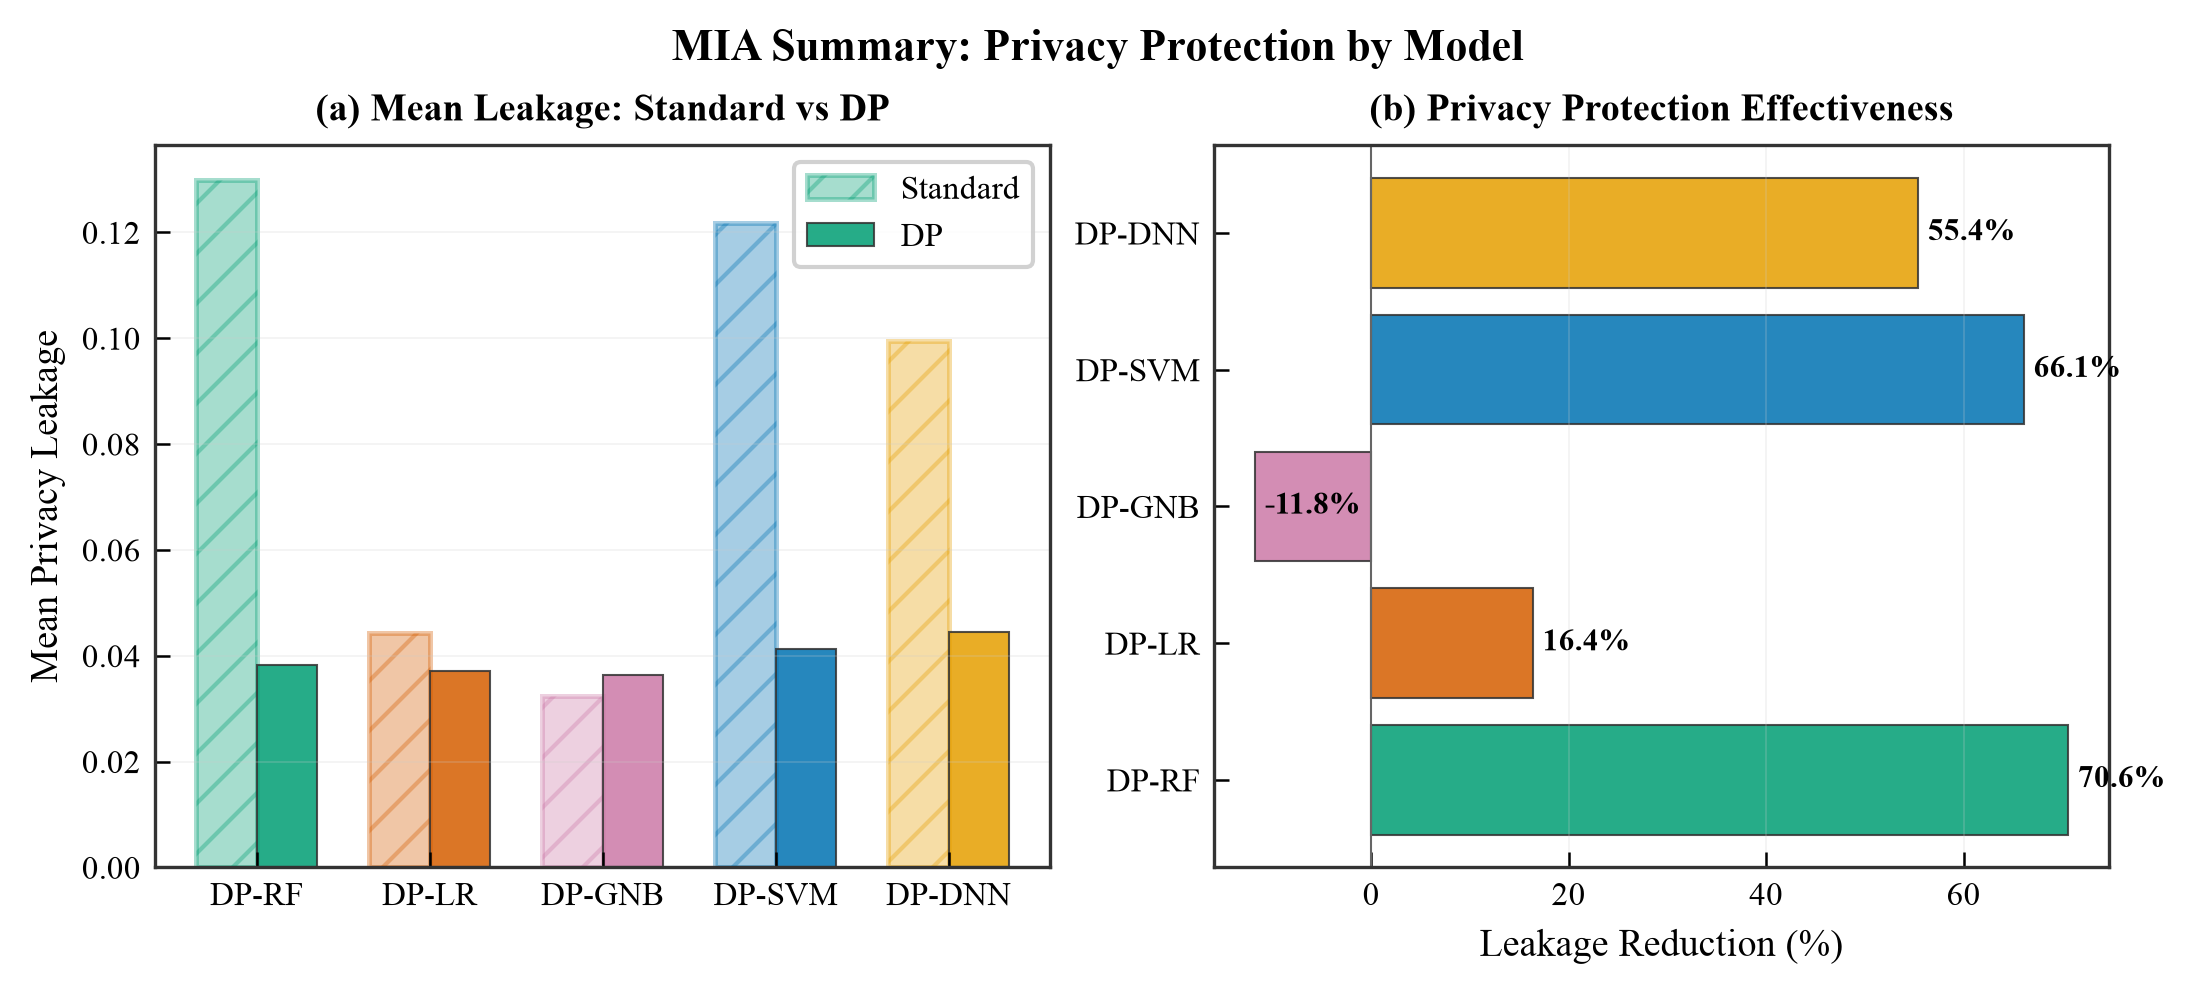

Saved: fig5b_summary_bar_chart.pdf / .png


In [9]:
# Also create a bar chart version of summary stats for visual impact
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2))

# Left: Mean leakage comparison (DP vs Standard)
ax = axes[0]
x = np.arange(len(MODELS_ORDER))
width = 0.35

dp_means = [df_dp[df_dp['model'] == m]['advantage_mean'].mean() for m in MODELS_ORDER]
std_means = [df_baseline[df_baseline['model'] == m.replace('DP-', 'Standard ')]['advantage_mean'].mean()
             for m in MODELS_ORDER]

bars1 = ax.bar(x - width/2, std_means, width, label='Standard',
               color=[MODEL_COLORS[m] for m in MODELS_ORDER], alpha=0.35,
               edgecolor=[MODEL_COLORS[m] for m in MODELS_ORDER], linewidth=1.2, hatch='//')
bars2 = ax.bar(x + width/2, dp_means, width, label='DP',
               color=[MODEL_COLORS[m] for m in MODELS_ORDER], alpha=0.85,
               edgecolor='#333333', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(MODELS_ORDER, fontsize=8)
ax.set_ylabel('Mean Privacy Leakage', fontsize=9)
ax.set_title('(a) Mean Leakage: Standard vs DP', fontweight='bold', fontsize=9)
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, axis='y', alpha=0.25, linestyle='-', color='#cccccc')
ax.axhline(0, color='#666666', linewidth=0.5)

# Right: Reduction percentage
ax = axes[1]
reductions = []
for m in MODELS_ORDER:
    dp_mean = df_dp[df_dp['model'] == m]['advantage_mean'].mean()
    std_mean = df_baseline[df_baseline['model'] == m.replace('DP-', 'Standard ')]['advantage_mean'].mean()
    red = ((std_mean - dp_mean) / std_mean * 100) if std_mean > 0 else 0
    reductions.append(red)

bars = ax.barh(x, reductions, color=[MODEL_COLORS[m] for m in MODELS_ORDER],
               edgecolor='#333333', linewidth=0.5, alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(MODELS_ORDER, fontsize=8)
ax.set_xlabel('Leakage Reduction (%)', fontsize=9)
ax.set_title('(b) Privacy Protection Effectiveness', fontweight='bold', fontsize=9)
ax.grid(True, axis='x', alpha=0.25, linestyle='-', color='#cccccc')
ax.axvline(0, color='#666666', linewidth=0.5)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, reductions)):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=7.5, fontweight='bold')

fig.suptitle('MIA Summary: Privacy Protection by Model', fontsize=10.5, fontweight='bold')

plt.savefig(GRAPH_DIR / f'{ATTACK}_fig5b_summary_bar_chart.pdf', format='pdf', bbox_inches='tight')
plt.savefig(GRAPH_DIR / f'{ATTACK}_fig5b_summary_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig5b_summary_bar_chart.pdf / .png")

---
## Output Summary

In [10]:
print("=" * 70)
print(f"{'ALL GENERATED FIGURES':^70}")
print("=" * 70)
print(f"Output directory: {GRAPH_DIR}")
print("-" * 70)
for f in sorted(GRAPH_DIR.glob('*.pdf')):
    print(f"  {f.name}")
print("=" * 70)

                        ALL GENERATED FIGURES                         
Output directory: figures
----------------------------------------------------------------------
  baseline_lira_auc.pdf
  baseline_lira_tpr_at_1pct.pdf
  baseline_shokri_auc.pdf
  baseline_yeom_advantage.pdf
  lira_fig1_breast_cancer_privacy_leakage.pdf
  lira_fig1_cancer_risk_privacy_leakage.pdf
  lira_fig1_diabetes_privacy_leakage.pdf
  lira_fig1_gallstone_privacy_leakage.pdf
  lira_fig1_kidney_stone_privacy_leakage.pdf
  lira_fig1_lung_cancer_privacy_leakage.pdf
  lira_fig2_privacy_leakage_lollipop.pdf
  lira_fig3_dp_dnn_privacy_leakage.pdf
  lira_fig3_dp_gnb_privacy_leakage.pdf
  lira_fig3_dp_lr_privacy_leakage.pdf
  lira_fig3_dp_rf_privacy_leakage.pdf
  lira_fig3_dp_svm_privacy_leakage.pdf
  lira_fig4_privacy_leakage_summary_heatmap.pdf
  lira_fig5_summary_statistics_table.pdf
  lira_fig5b_summary_bar_chart.pdf
  shokri_fig1_breast_cancer_privacy_leakage.pdf
  shokri_fig1_cancer_risk_privacy_leakage.pdf
  shok

---

## Baseline (non-private) leakage across all three attacks

These four figures pull directly from `consolidated_mia_data.csv` — `variant == 'standard'` rows only, across `yeom`, `lira` and `shokri` — independent of the `ATTACK` selector above. Bare model names (`RF`, `LR`, `GNB`, `SVM`, `DNN`), grouped bar per dataset, dashed line marks the random-guess baseline where one applies (0.5 for AUC, 1% for TPR@1%FPR; Yeom advantage has no such line since random advantage is 0, shown by the y=0 axis itself).


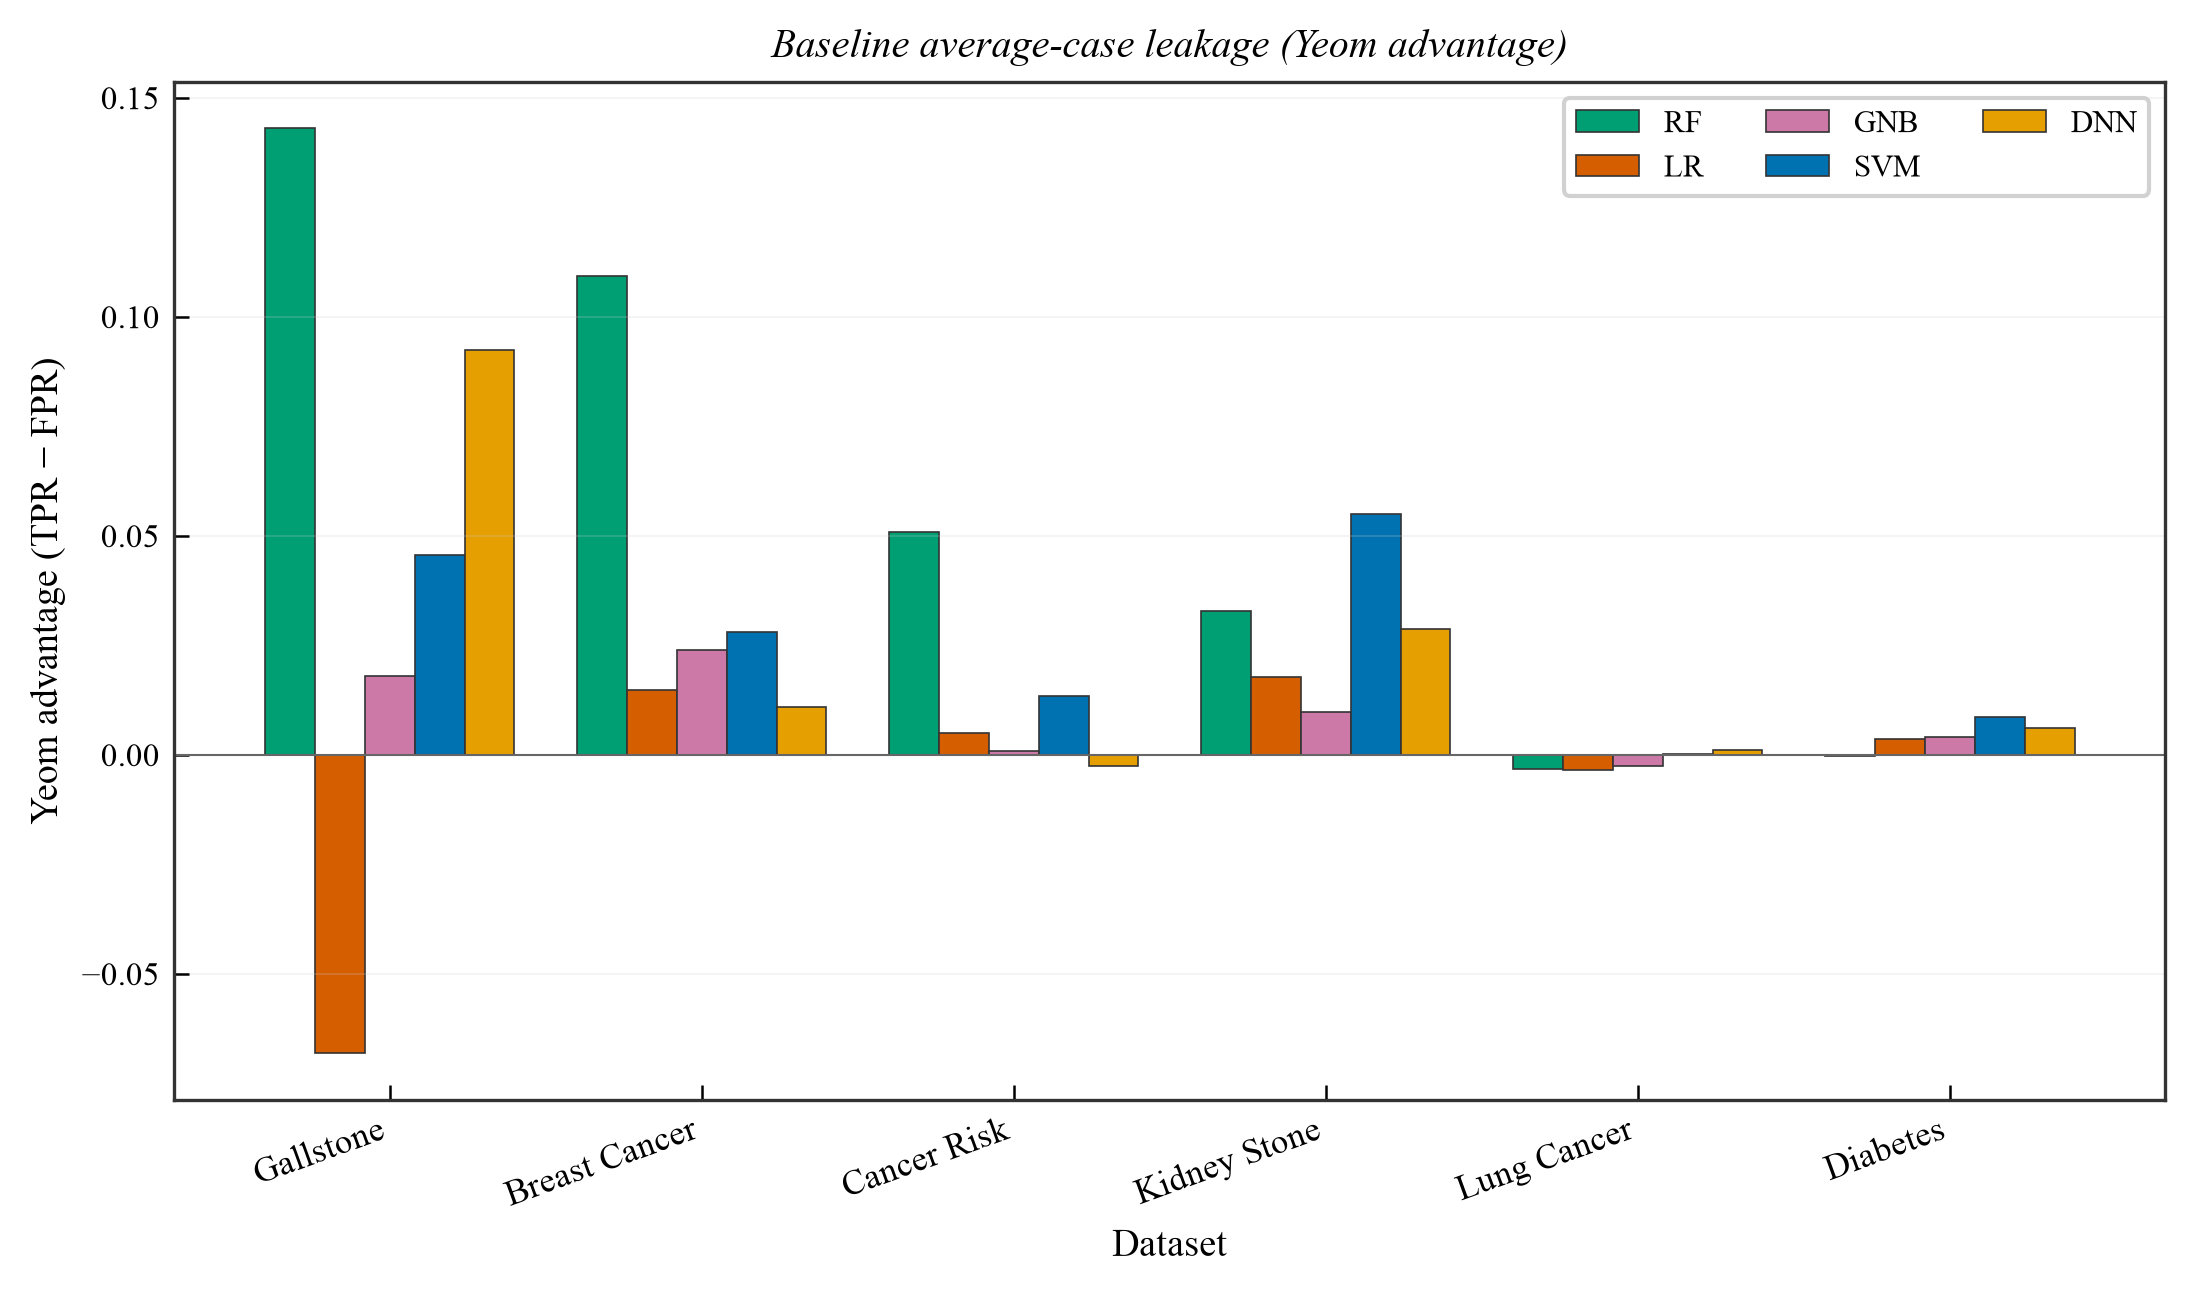

Saved: baseline_yeom_advantage.pdf / .png


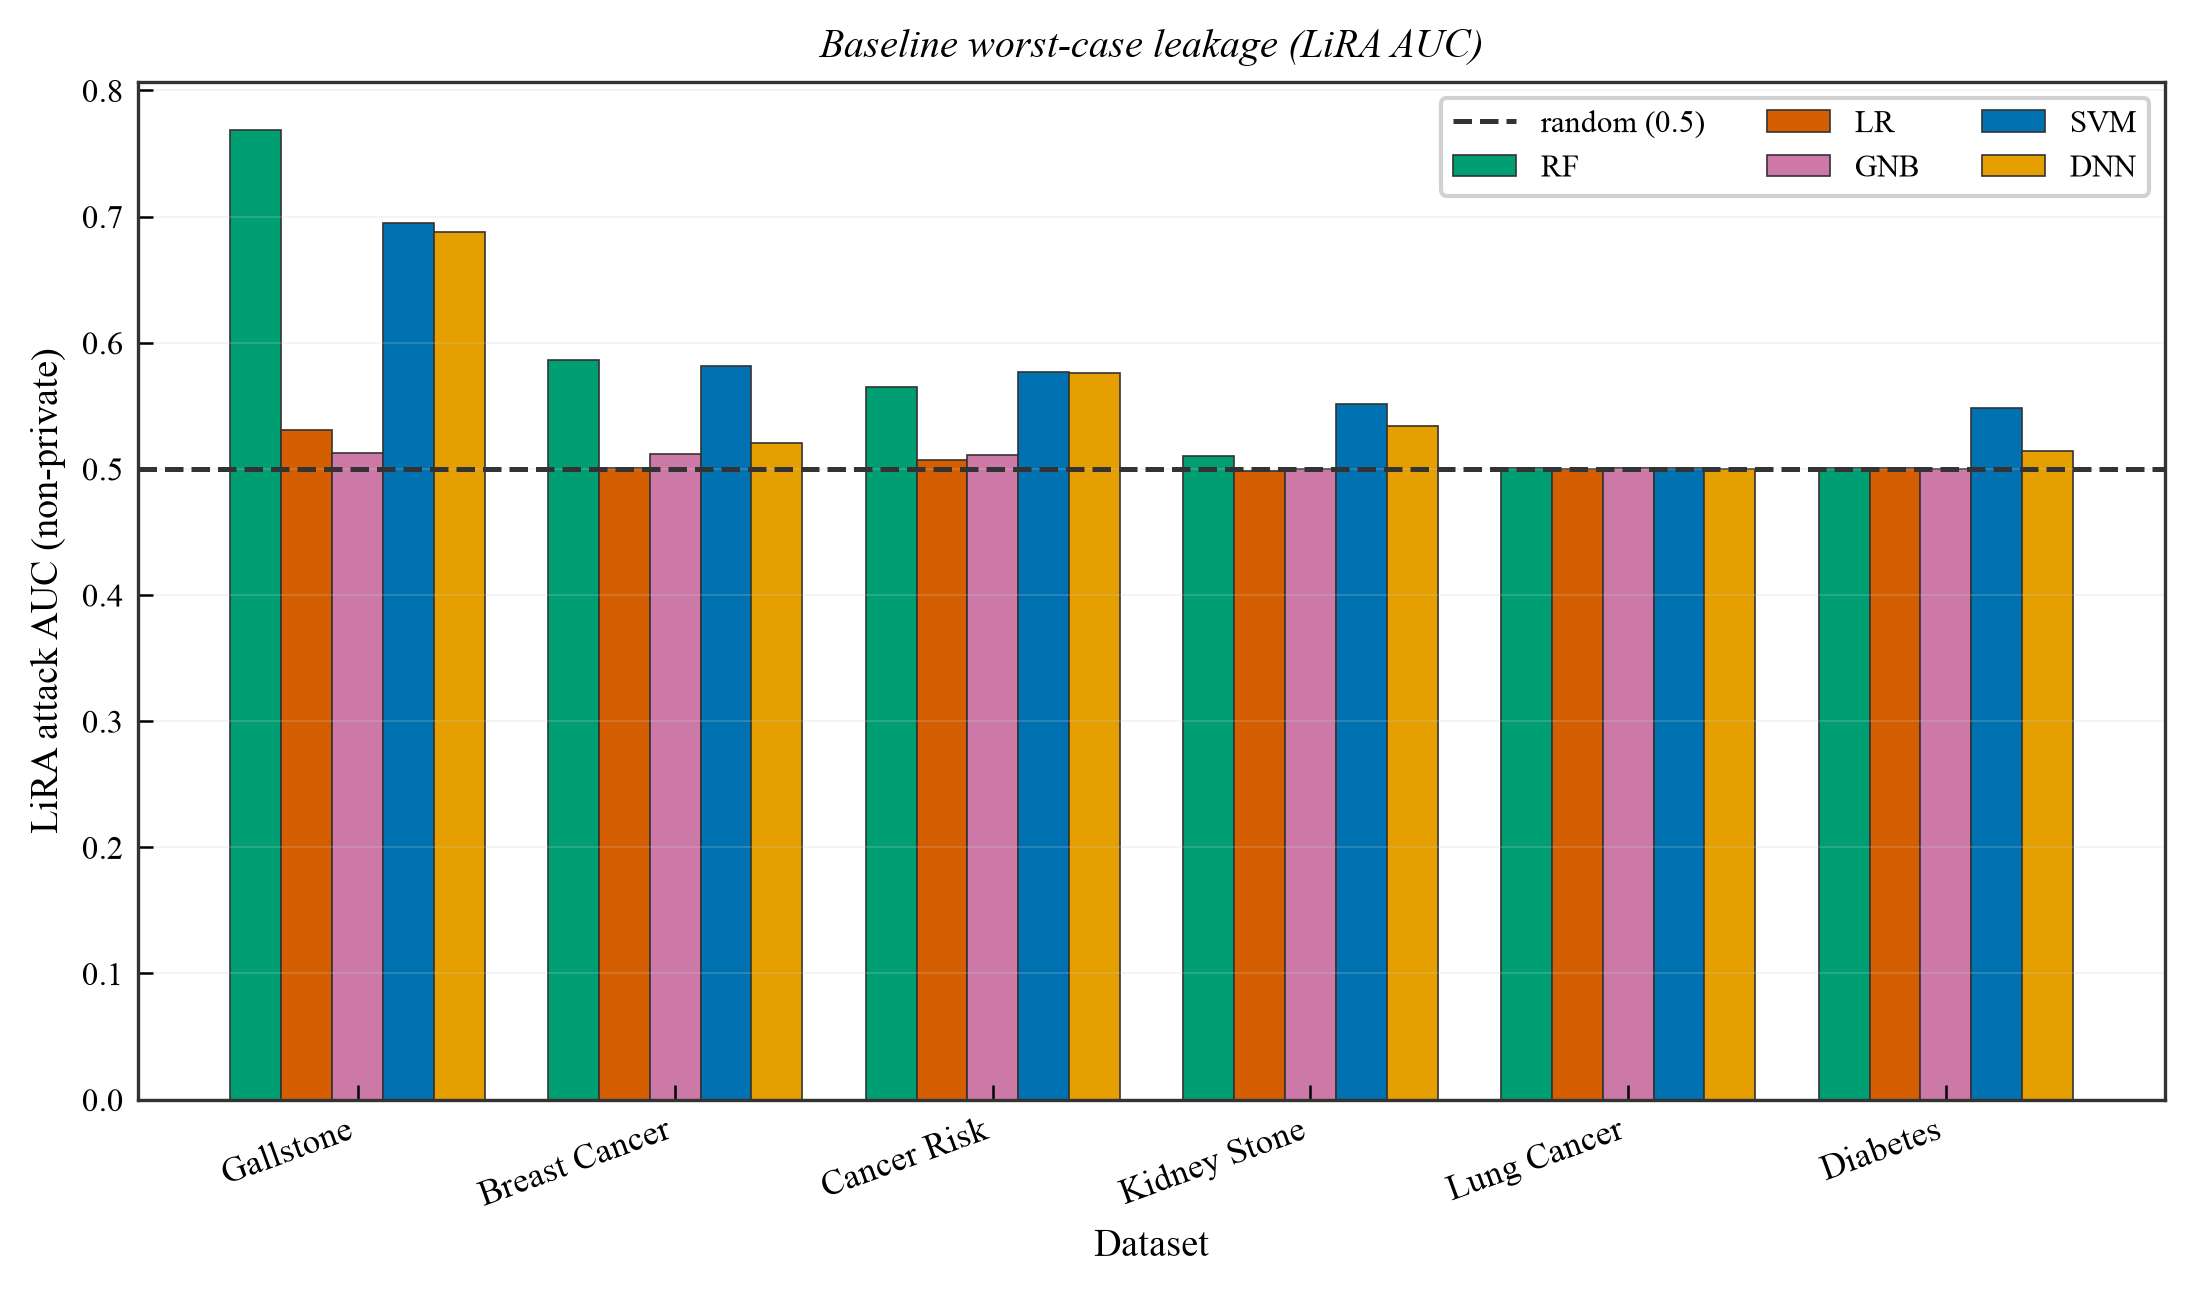

Saved: baseline_lira_auc.pdf / .png


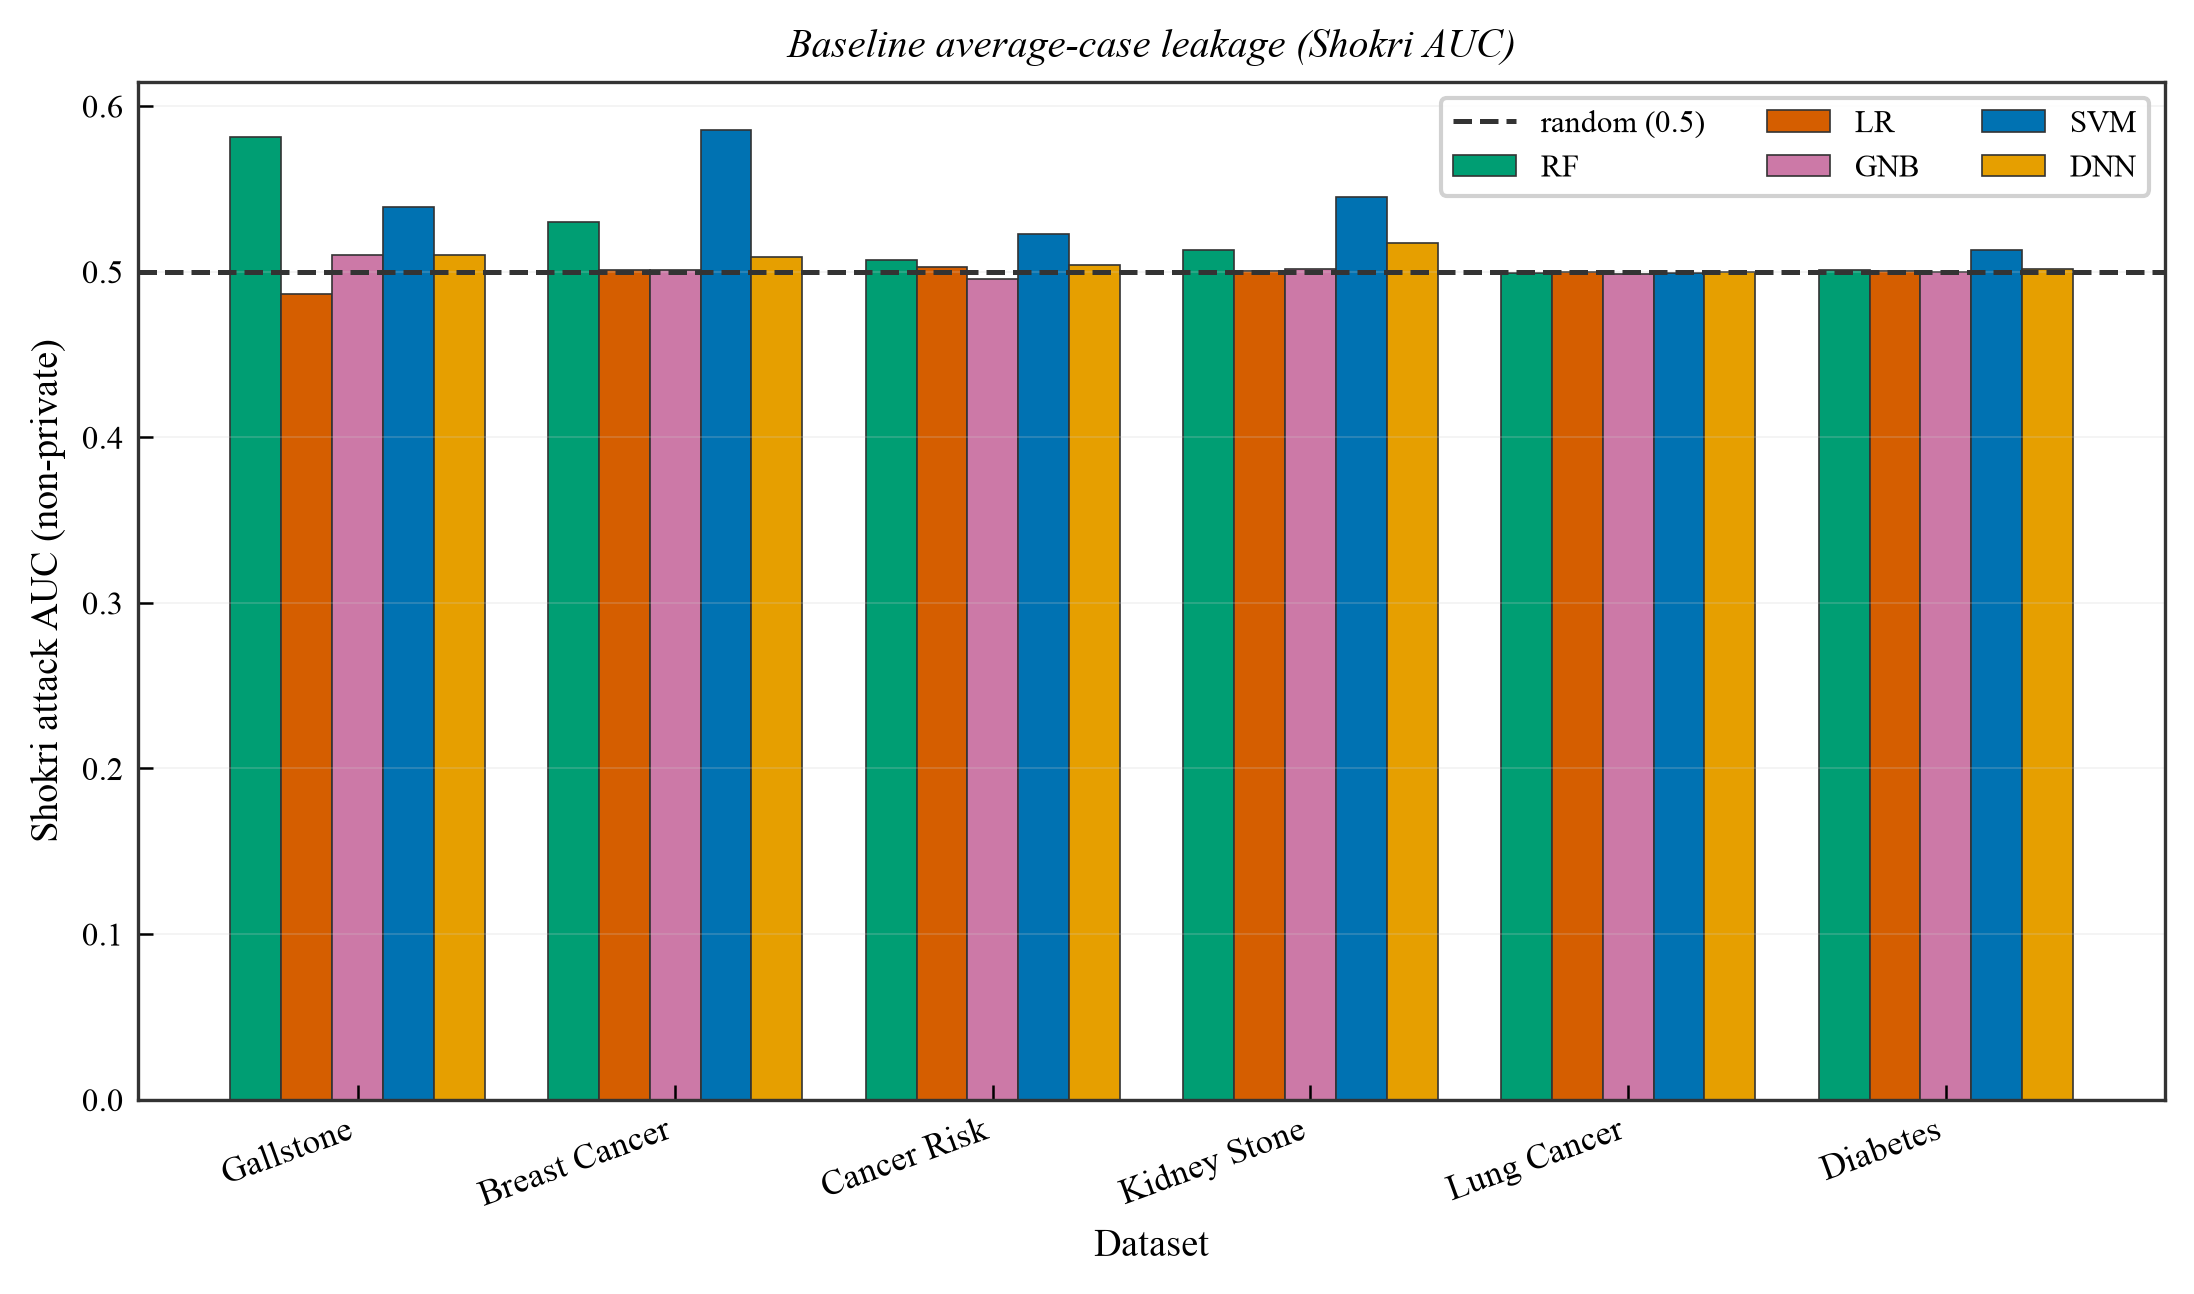

Saved: baseline_shokri_auc.pdf / .png


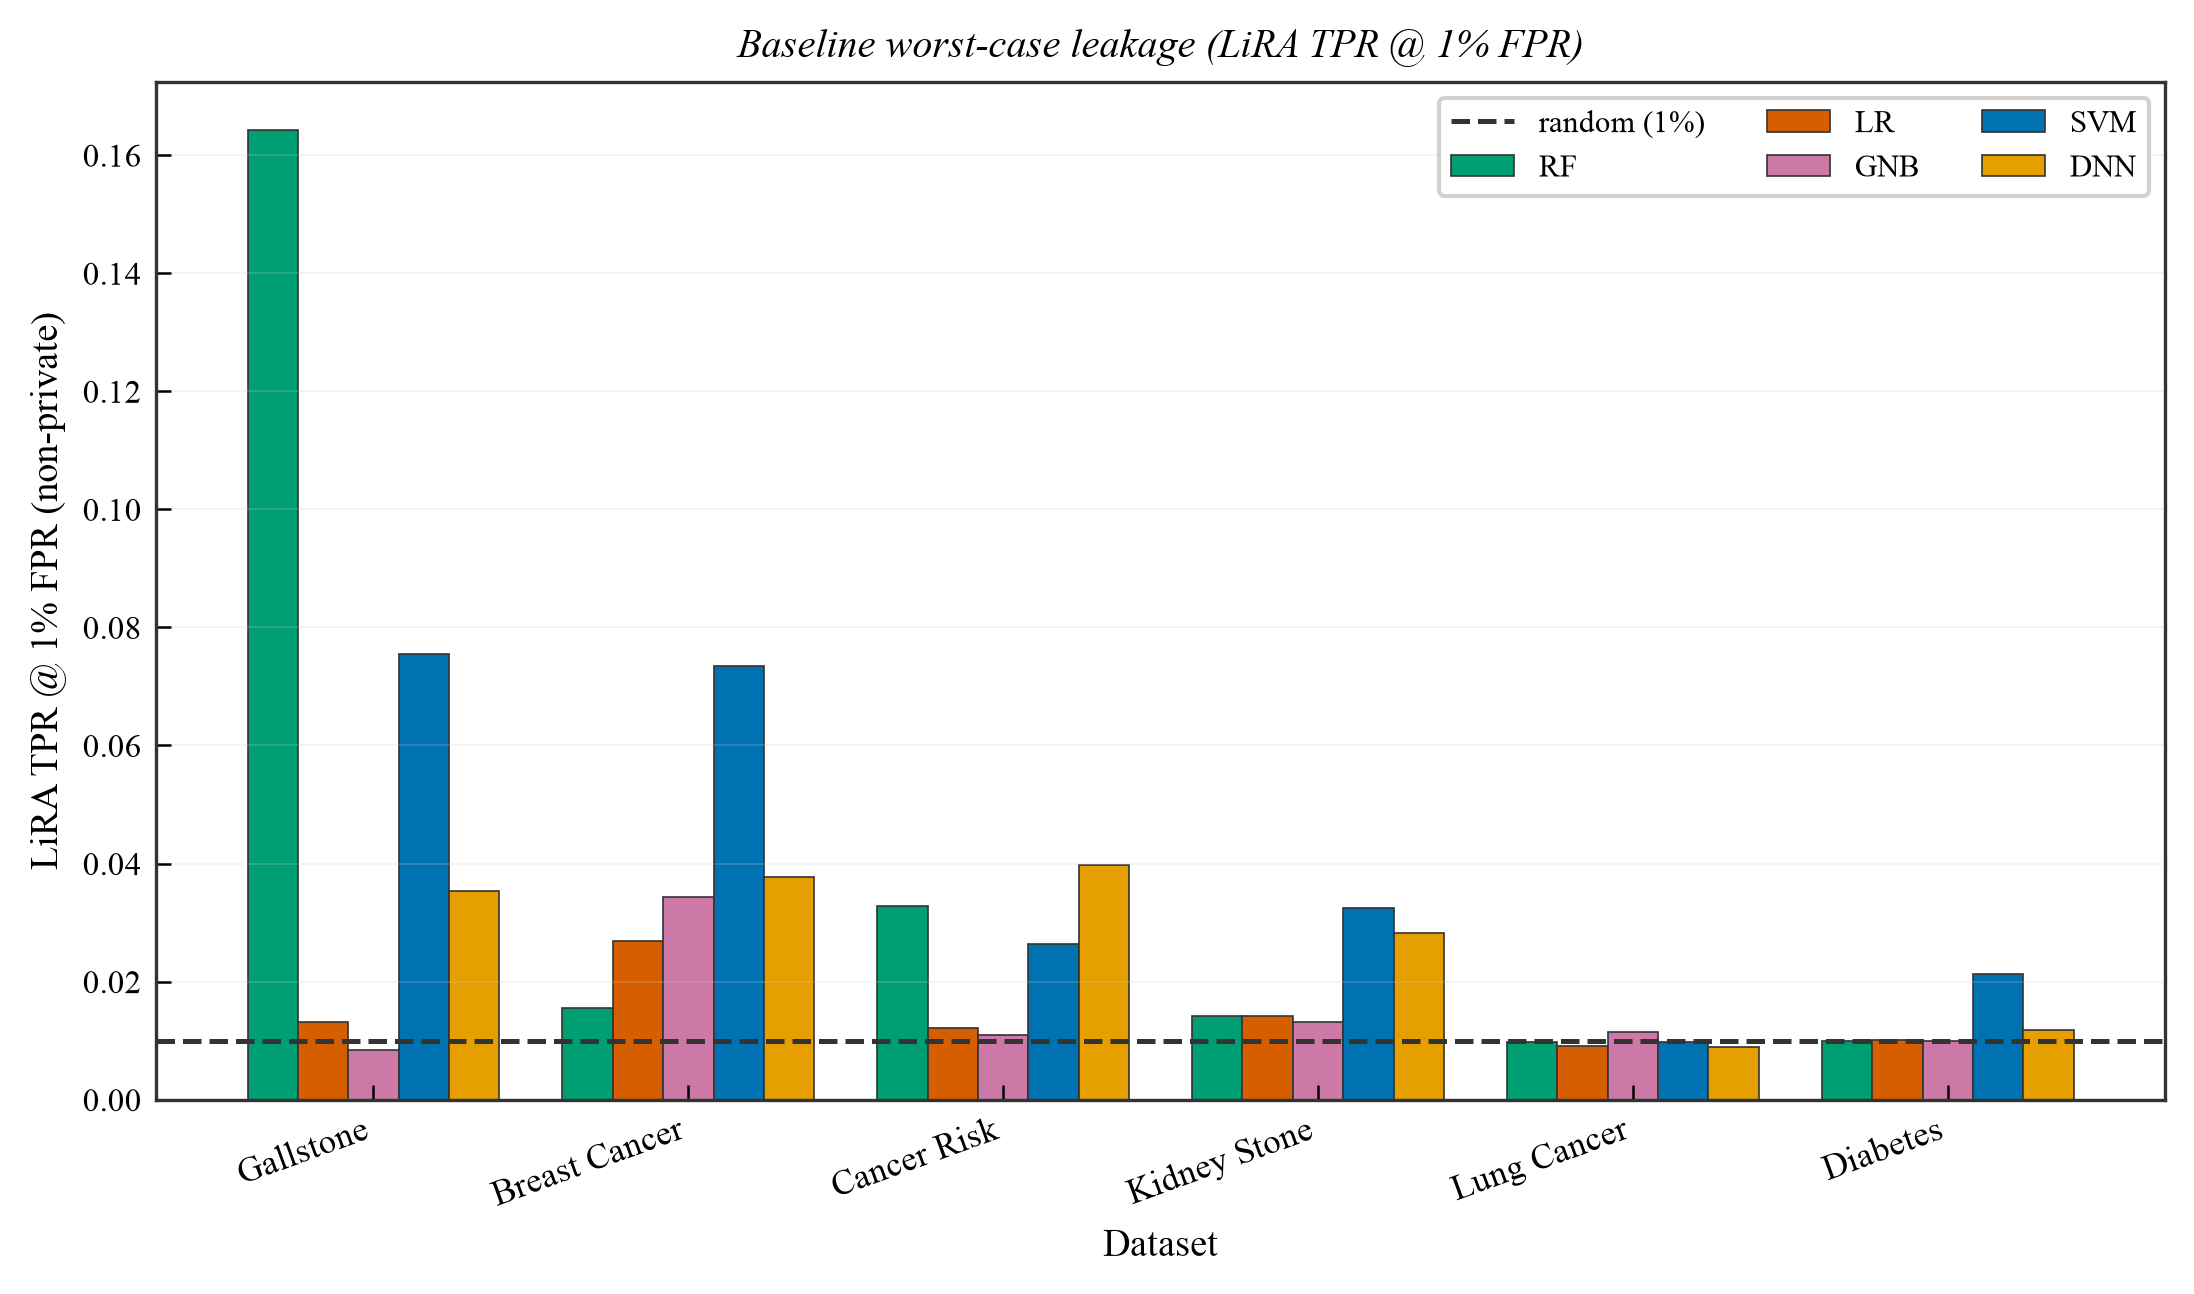

Saved: baseline_lira_tpr_at_1pct.pdf / .png


In [11]:
MCOLOR  = {'RF': '#009E73', 'LR': '#D55E00', 'GNB': '#CC79A7', 'SVM': '#0072B2', 'DNN': '#E69F00'}
MMARKER = {'RF': 'o',       'LR': 's',       'GNB': '^',       'SVM': 'D',       'DNN': 'v'}
MLINE   = {'RF': '-',       'LR': '--',      'GNB': '-.',      'SVM': ':',       'DNN': (0, (3, 1, 1, 1))}

# Paul Tol muted — dataset colours, consistent with graph_construction.ipynb
DCOLOR  = {
    'Breast Cancer': '#CC6677',
    'Cancer Risk':   '#DDCC77',
    'Diabetes':      '#117733',
    'Gallstone':     '#332288',
    'Kidney Stone':  '#88CCEE',
    'Lung Cancer':   '#AA4499',
}

MODELS_BARE = ['RF', 'LR', 'GNB', 'SVM', 'DNN']


def plot_baseline_leakage(attack, metric, ylabel, title, savename,
                           random_line=None, random_label=None):
    """Grouped bar chart: one bar per model, one group per dataset, standard variant only."""
    data = df_raw[(df_raw['attack'] == attack) & (df_raw['variant'] == 'standard')]

    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    n_models = len(MODELS_BARE)
    width = 0.8 / n_models
    x = np.arange(len(DATASETS_ORDER))

    for i, model in enumerate(MODELS_BARE):
        vals = []
        for ds in DATASETS_ORDER:
            row = data[(data['dataset'] == ds) & (data['model'] == model)]
            vals.append(row[metric].values[0] if not row.empty else np.nan)
        ax.bar(
            x + (i - (n_models - 1) / 2) * width, vals, width,
            color=MCOLOR[model], label=model,
            edgecolor='#333333', linewidth=0.4
        )

    if random_line is not None:
        ax.axhline(random_line, color='#333333', linestyle='--', linewidth=1.2,
                   label=random_label, zorder=10)

    ax.set_xticks(x)
    ax.set_xticklabels(DATASETS_ORDER, rotation=20, ha='right', fontsize=8.5)
    ax.set_xlabel('Dataset', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=9.5, style='italic')
    ax.grid(True, axis='y', alpha=0.25, linestyle='-', color='#cccccc')
    ax.axhline(0, color='#666666', linewidth=0.5)
    ax.legend(ncol=3, fontsize=7.5, loc='upper right', framealpha=0.9)

    plt.savefig(GRAPH_DIR / f'{savename}.pdf', format='pdf', bbox_inches='tight')
    plt.savefig(GRAPH_DIR / f'{savename}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {savename}.pdf / .png")


BASELINE_SPECS = [
    ('yeom', 'advantage_mean', 'Yeom advantage (TPR \u2212 FPR)',
     'Baseline average-case leakage (Yeom advantage)',
     'baseline_yeom_advantage', None, None),
    ('lira', 'attack_auc_mean', 'LiRA attack AUC (non-private)',
     'Baseline worst-case leakage (LiRA AUC)',
     'baseline_lira_auc', 0.5, 'random (0.5)'),
    ('shokri', 'attack_auc_mean', 'Shokri attack AUC (non-private)',
     'Baseline average-case leakage (Shokri AUC)',
     'baseline_shokri_auc', 0.5, 'random (0.5)'),
    ('lira', 'tpr_at_1pct', 'LiRA TPR @ 1% FPR (non-private)',
     'Baseline worst-case leakage (LiRA TPR @ 1% FPR)',
     'baseline_lira_tpr_at_1pct', 0.01, 'random (1%)'),
]

for attack, metric, ylabel, title, savename, rline, rlabel in BASELINE_SPECS:
    plot_baseline_leakage(attack, metric, ylabel, title, savename, rline, rlabel)
